In [1]:
import cloudpickle

results_pikl = "pikls/20260202_135312/all_datasets_full.pkl"

#TChiWZ_17_pikl = "pikls/20251219_142853/TChiWZ2017UL.pkl"

with open(results_pikl, "rb") as f:
    json = cloudpickle.load(f)
    results = json["results"]

In [2]:
results.keys()

dict_keys(['SlepSnu2202602402023', 'SlepSnu2602802702023', 'SlepSnu2702802752023', 'TChiWZ2017UL', 'TTto2L2Nu2017UL', 'TTto2L2Nu2023'])

In [3]:
results[list(results.keys())[0]].keys()

dict_keys(['lpte_hist_tagged', 'lpte_hist'])

In [4]:
results[list(results.keys())[0]]["lpte_hist_tagged"]

Hist(
  Regular(10, 0, 10, name='pt', label='LowPtElectron $p_T$ (GeV)'),
  Regular(40, 1, 5, name='ID', label='LowPtElectron ID'),
  Variable([-2.5, -1.4442, -0.8, 0, 0.8, 1.4442, 2.5], name='eta', label='LowPtElectron $\\eta$'),
  Variable([-2.5, -1.48, -0.8, 0, 0.8, 1.48, 2.5], name='eta_old', label='LowPtElectron $\\eta$'),
  IntCategory([-10, 1, 10, 100, 1000], name='gen', label='LowPtElectron Gen Tag'),
  IntCategory([-1, 1, 10, 100], name='qual', label='LowPtElectron Quality Tag'),
  storage=Double()) # Sum: 72637.0 (507056.0 with flow)

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fbe71f8bd10>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fbe71fa2270>, text=[])

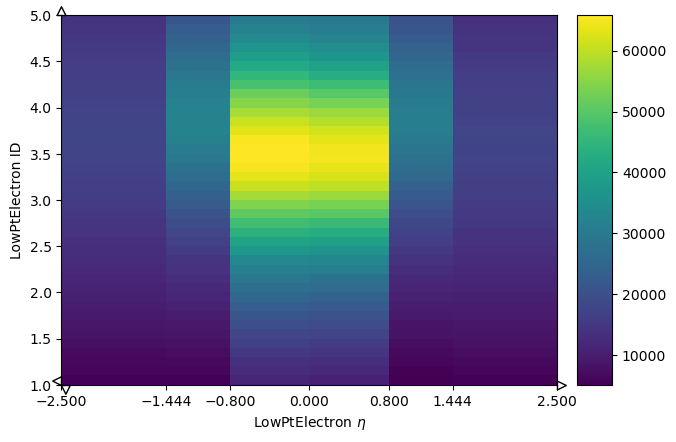

In [5]:
h = results['TChiWZ2017UL']['lpte_hist'].integrate("pt").integrate("eta_old").integrate("qual", [1j, 10j, 100j]).integrate("gen", [1j])
h.project("eta", "ID").plot()  # Specify order: eta first, then ID

In [6]:
from plotting.ID_eta_tuning import make_AN_ID_eta_plot

In [7]:
slepsnu_sig = results['SlepSnu2202602402023']["lpte_hist"].integrate("pt").integrate("eta_old").integrate("qual", [1j, 10j, 100j]).integrate("gen", [1j])
ttbar_2023_bg = results['TTto2L2Nu2023']["lpte_hist"].integrate("pt").integrate("eta_old").integrate("qual", [1j, 10j, 100j]).integrate("gen", [10j])

In [8]:
integrated_pt = make_AN_ID_eta_plot(
    slepsnu_sig,
    ttbar_2023_bg,
    title="Integrated $p_T$ (2 ≤ $p_T$ < 10 GeV)"
)

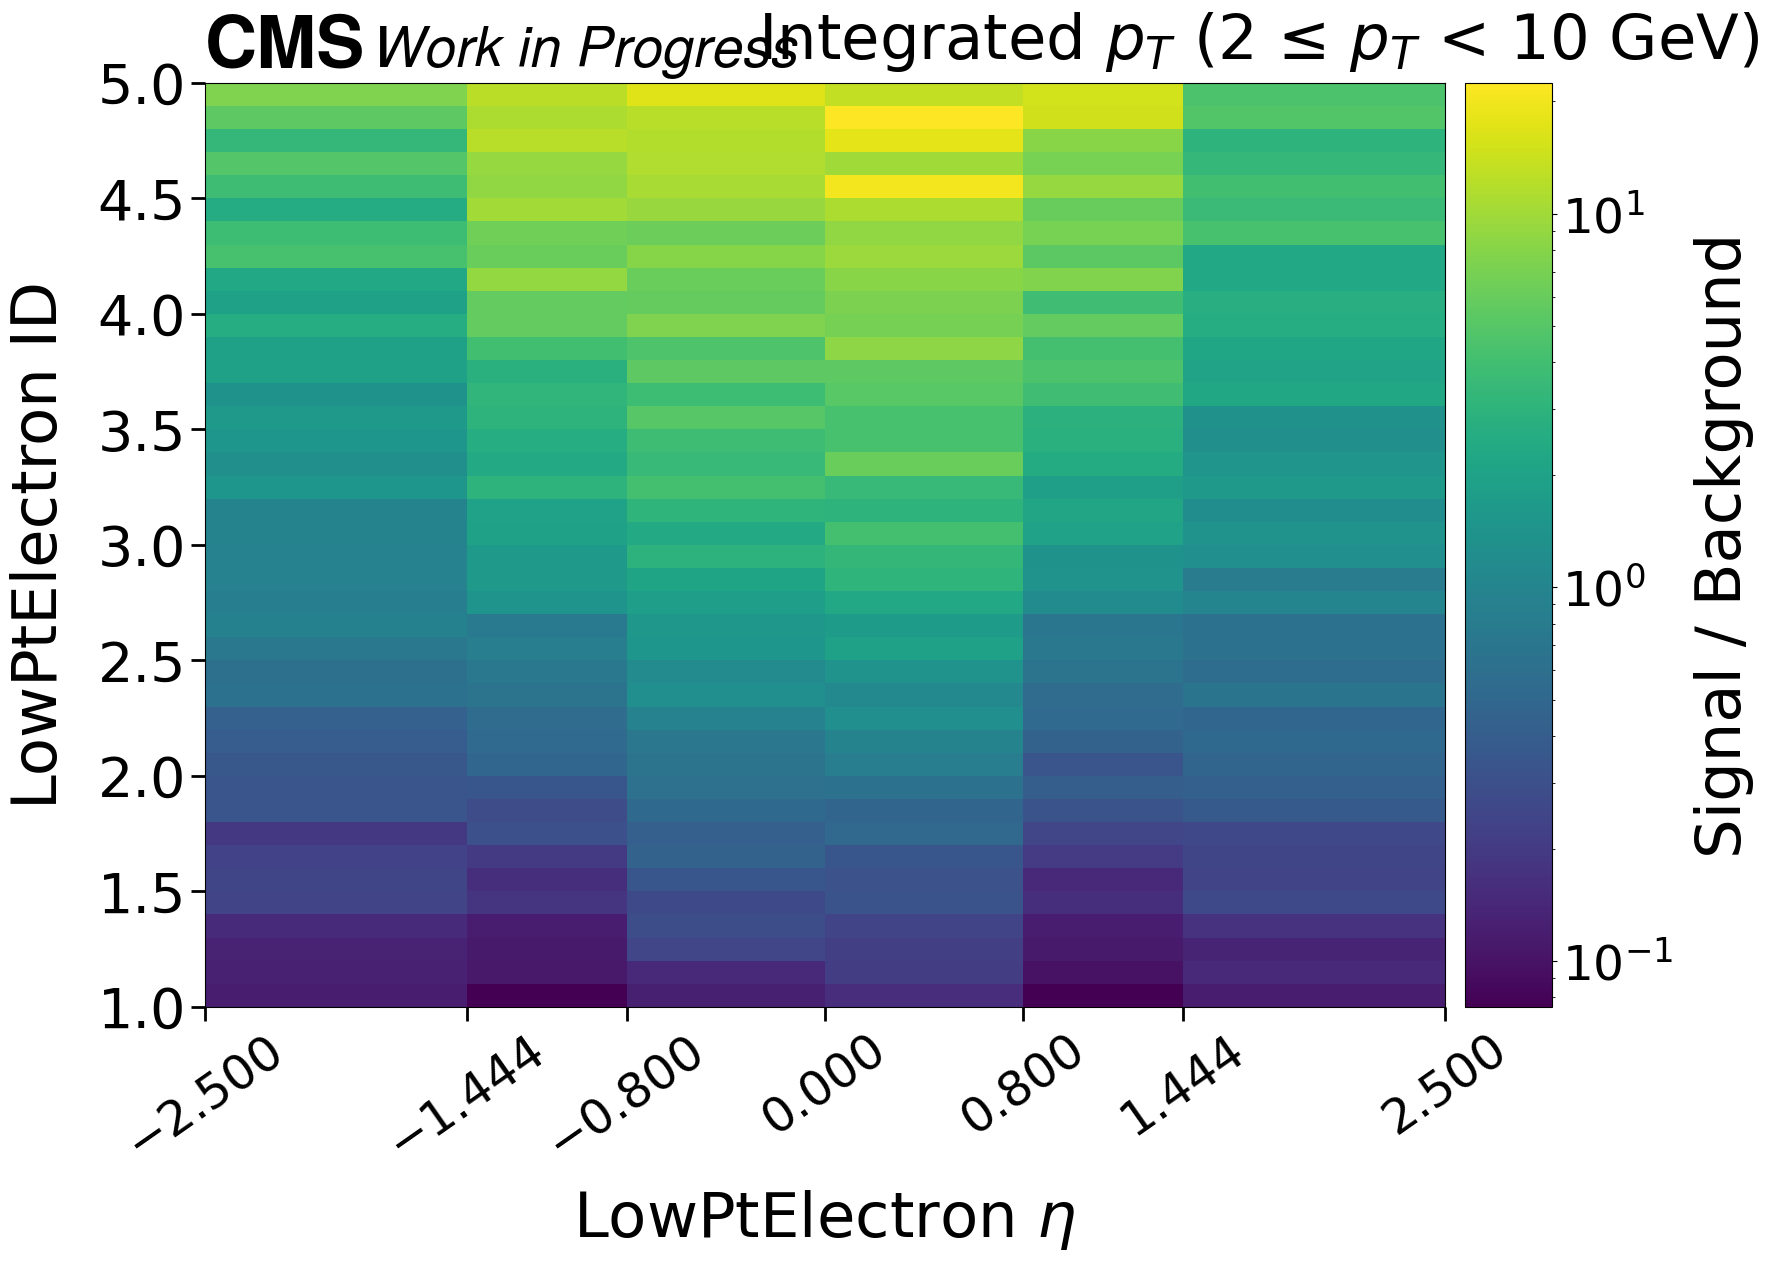

In [9]:
display(integrated_pt.figure)

In [10]:
pts = [2,3,4,5,6,7]

In [11]:
slepsnu_signal = results['SlepSnu2702802752023']["lpte_hist"].integrate("eta_old").integrate("qual", [1j, 10j, 100j]).integrate("gen", [1j])
ttbar_2023_background = results['TTto2L2Nu2023']["lpte_hist"].integrate("eta_old").integrate("qual", [1j, 10j, 100j]).integrate("gen", [10j])


In [12]:
slepsnu_signal

Hist(
  Regular(10, 0, 10, name='pt', label='LowPtElectron $p_T$ (GeV)'),
  Regular(40, 1, 5, name='ID', label='LowPtElectron ID'),
  Variable([-2.5, -1.4442, -0.8, 0, 0.8, 1.4442, 2.5], name='eta', label='LowPtElectron $\\eta$'),
  storage=Double()) # Sum: 23073.0 (73319.0 with flow)

In [13]:
slepsnu_signal[2j:3j, :, :]

Hist(
  Regular(1, 2, 3, name='pt', label='LowPtElectron $p_T$ (GeV)'),
  Regular(40, 1, 5, name='ID', label='LowPtElectron ID'),
  Variable([-2.5, -1.4442, -0.8, 0, 0.8, 1.4442, 2.5], name='eta', label='LowPtElectron $\\eta$'),
  storage=Double()) # Sum: 2967.0 (73319.0 with flow)

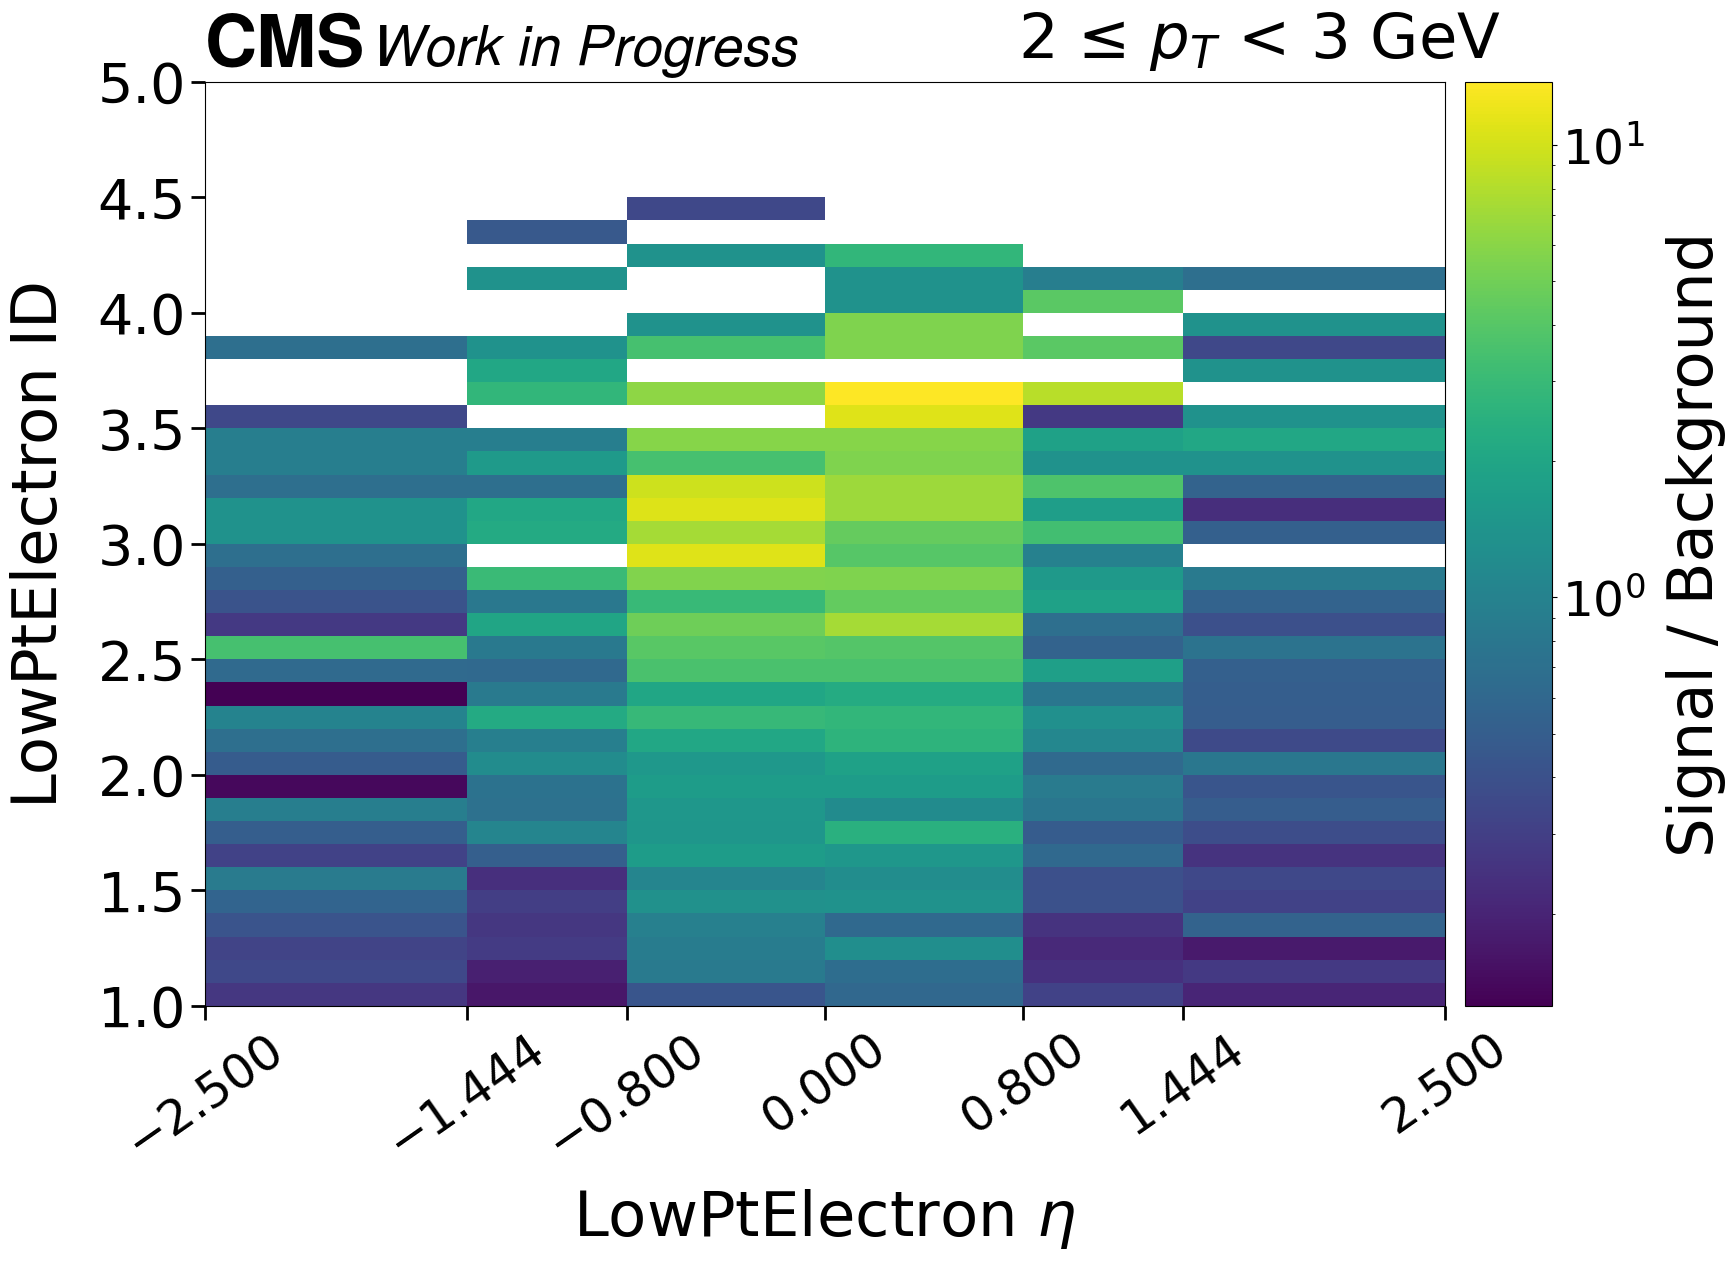

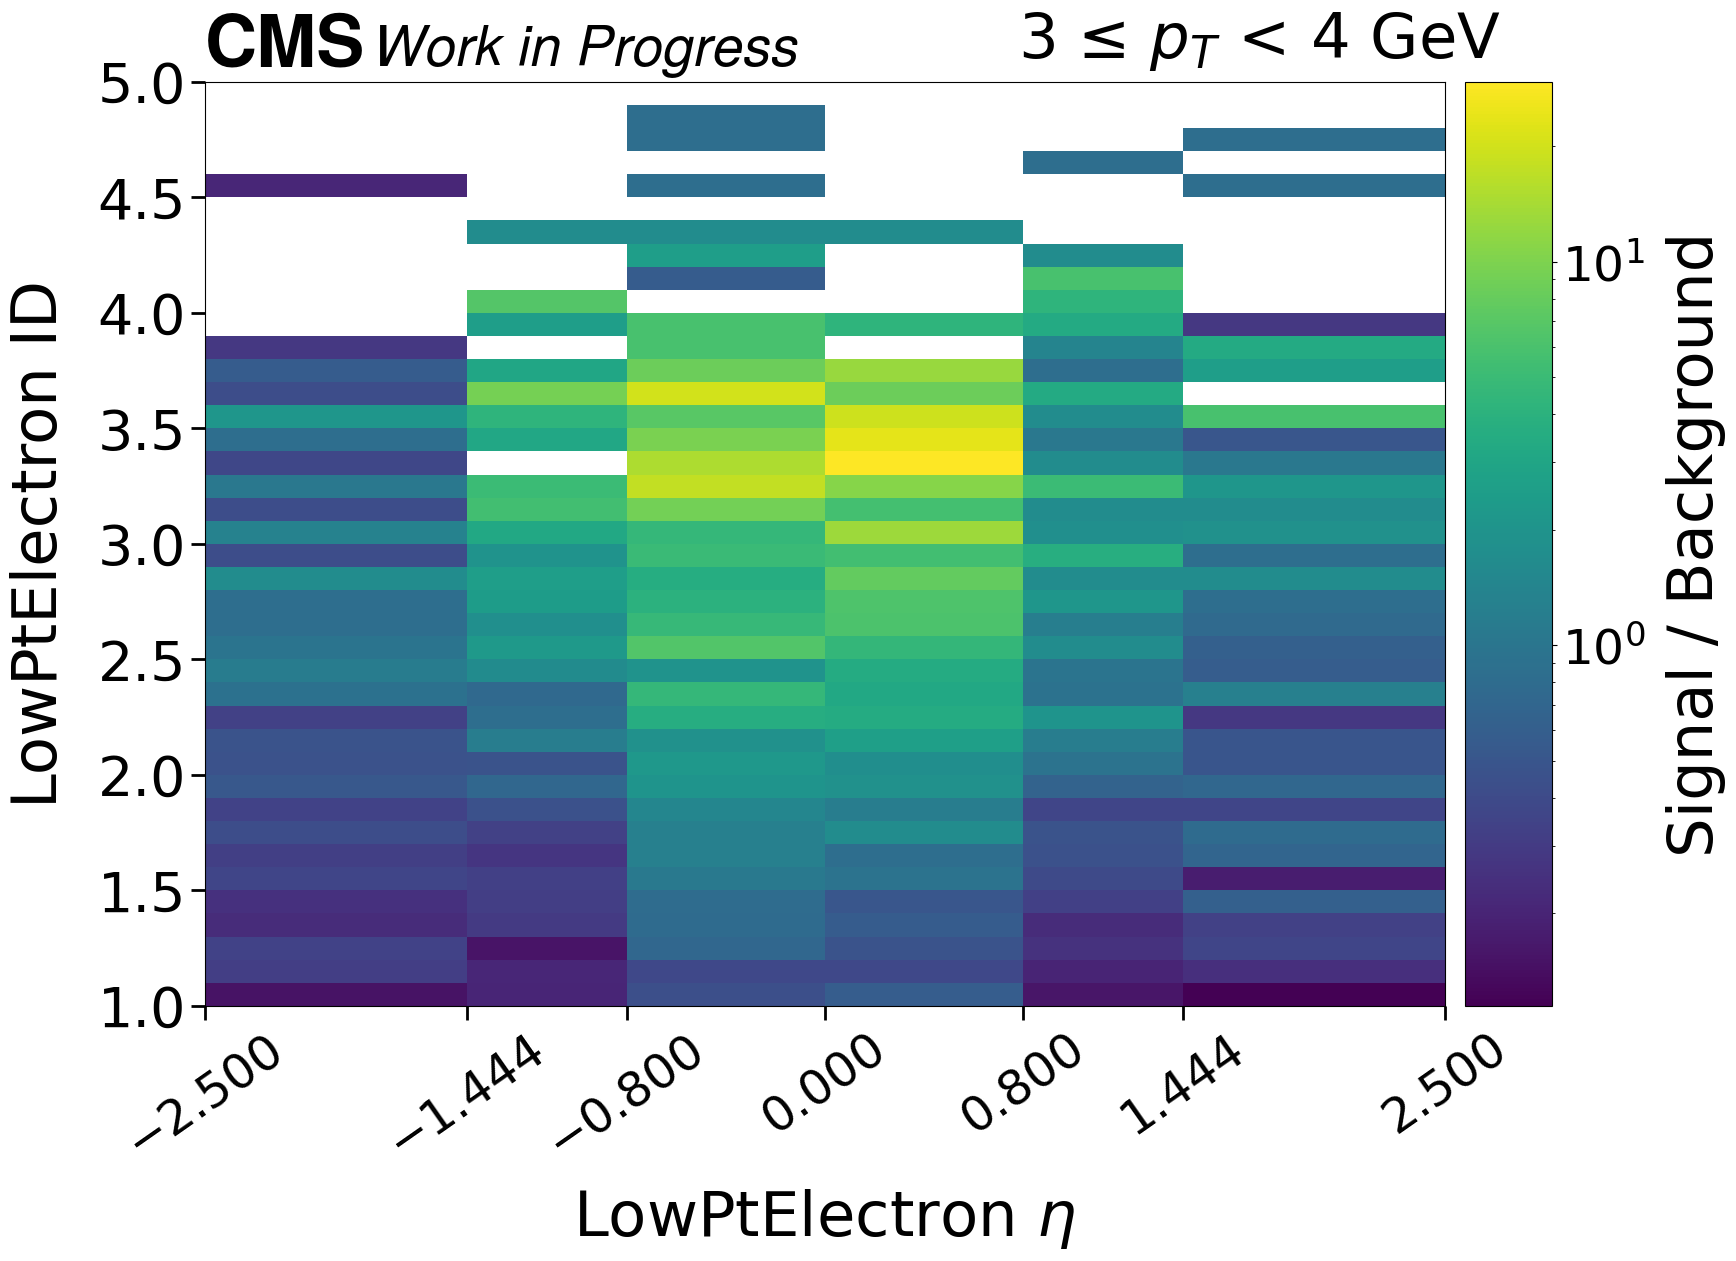

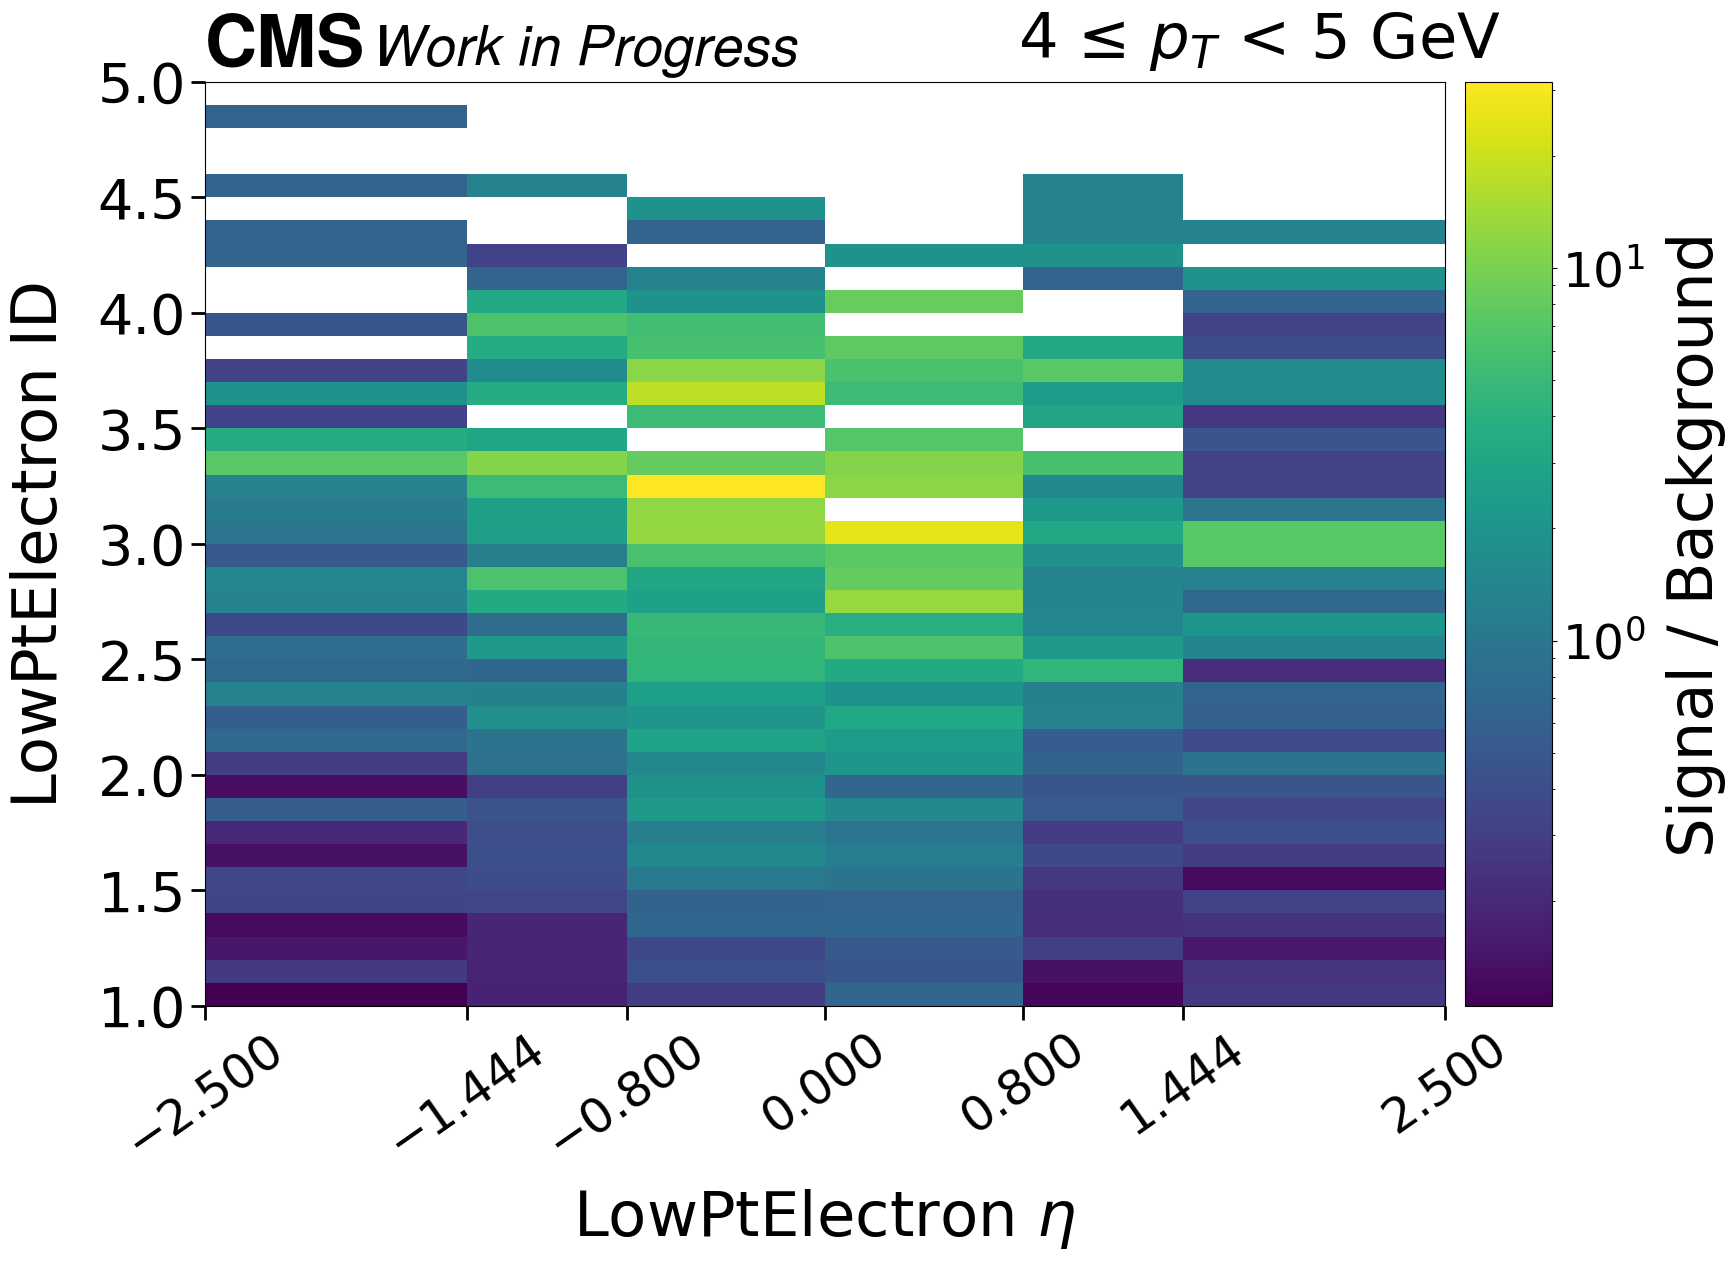

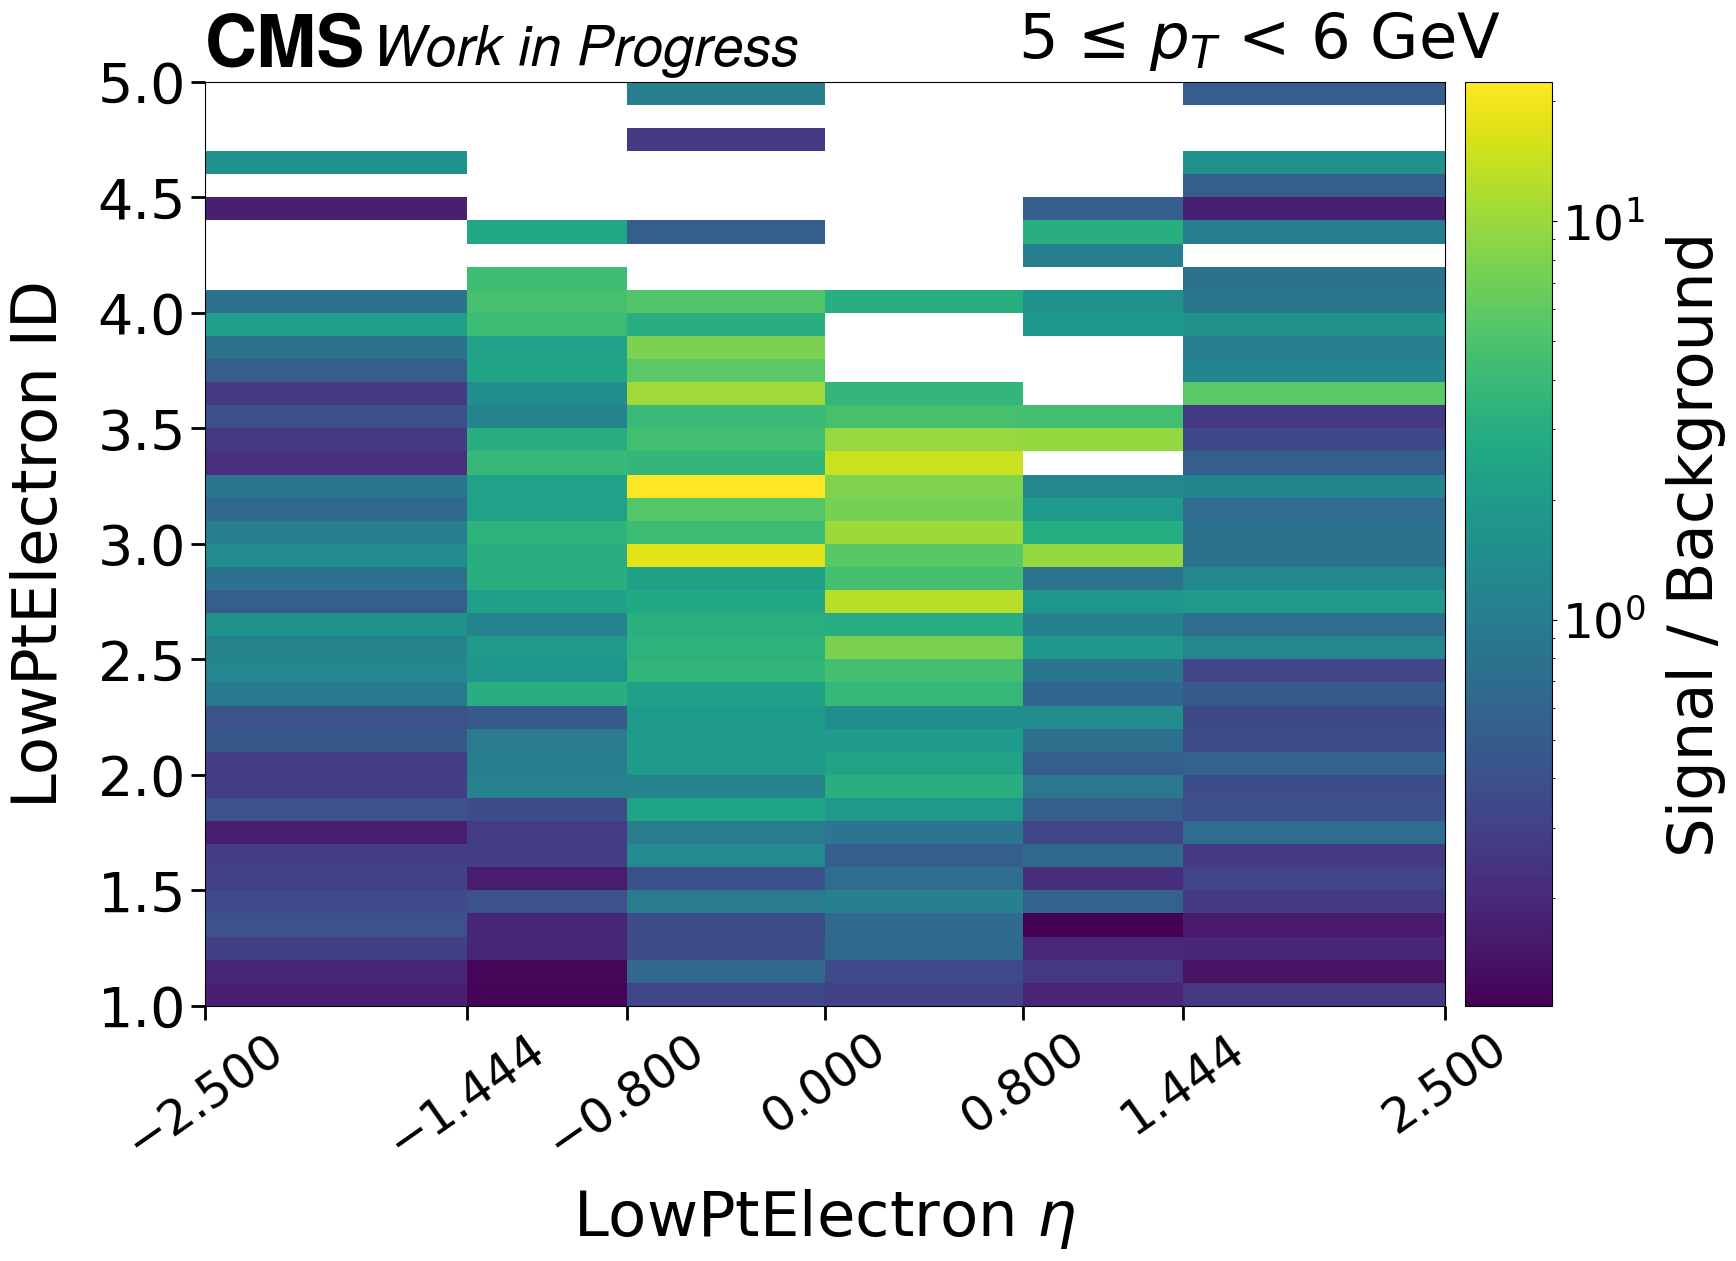

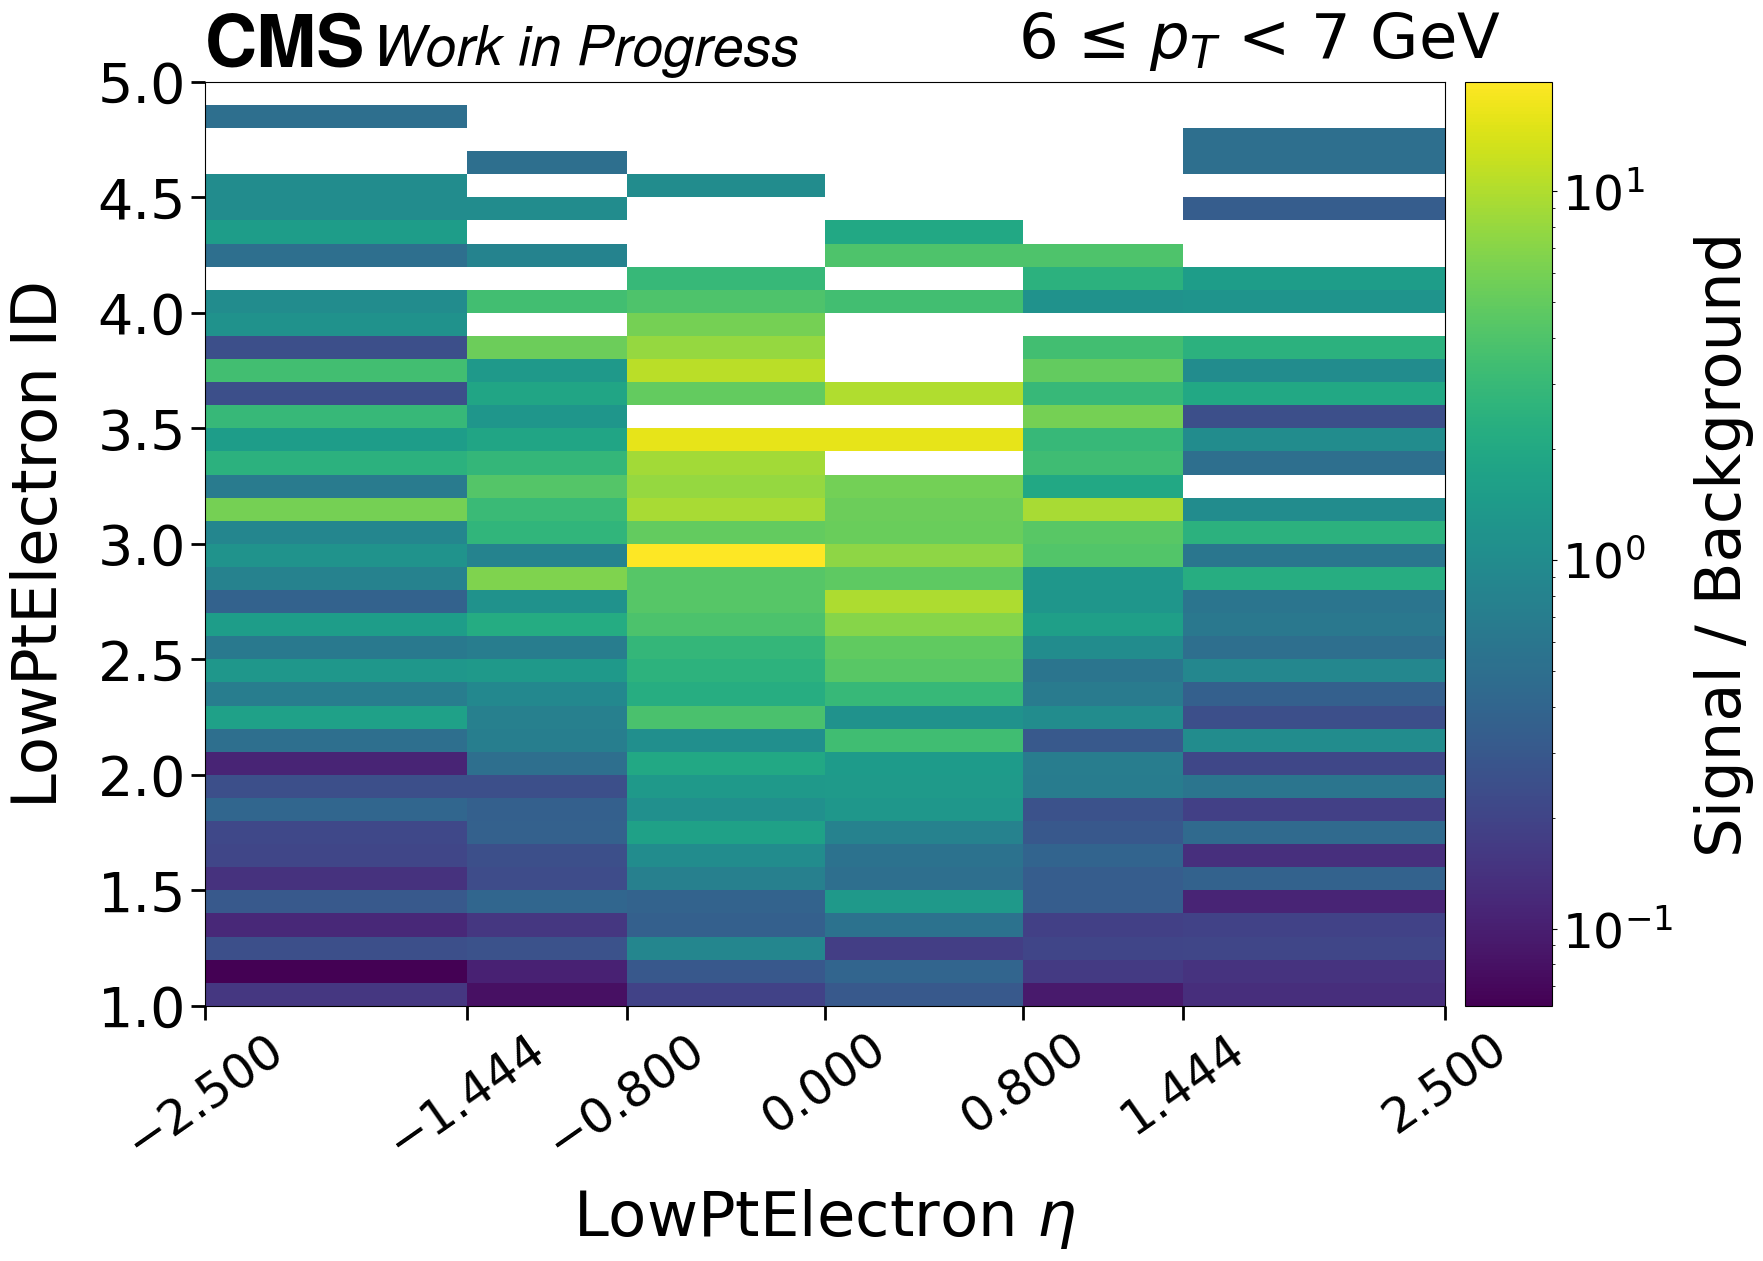

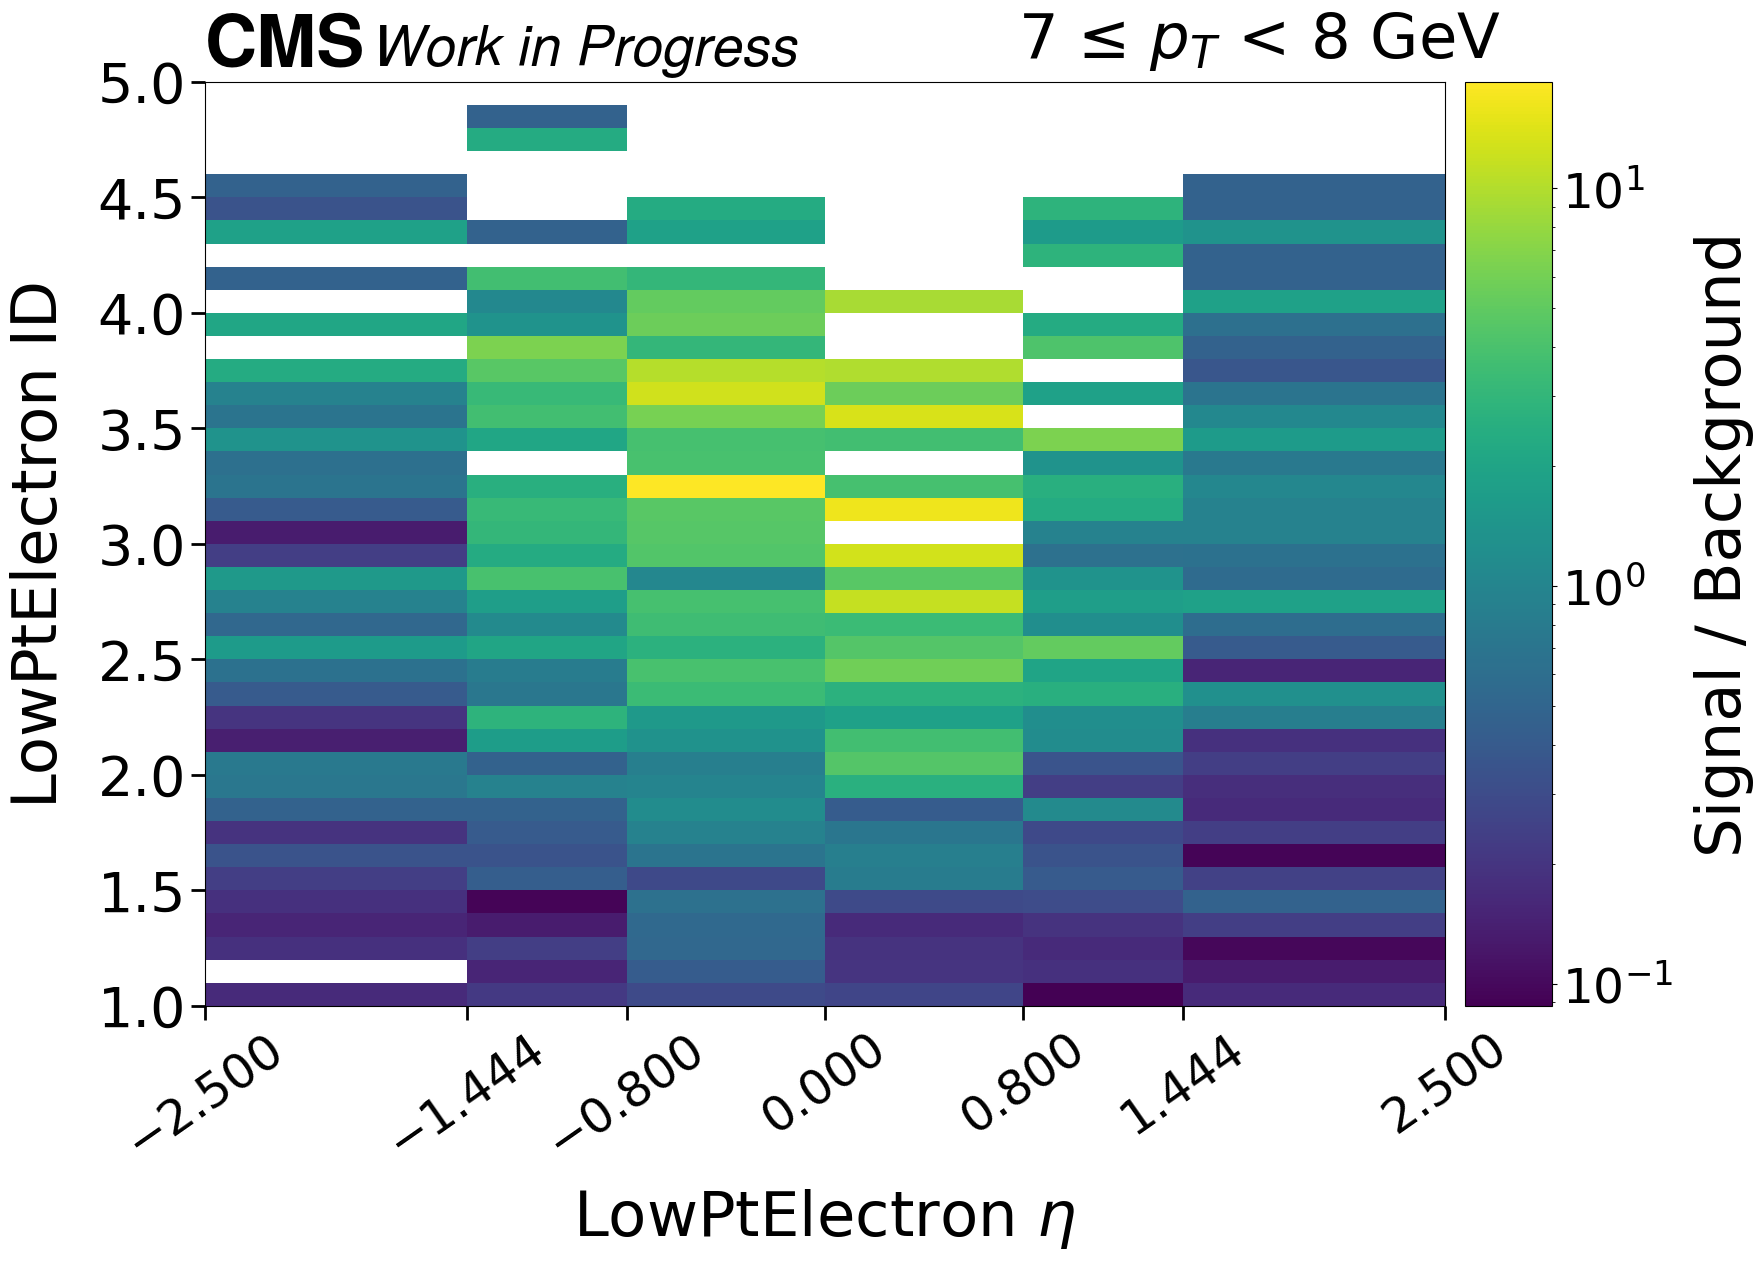

In [14]:
for pt in pts:
    result = make_AN_ID_eta_plot(
    slepsnu_signal[pt*1j:(pt+1)*1j, :,:],
    ttbar_2023_background[pt*1j:(pt+1)*1j, :,:],
    title=f"{pt} ≤ $p_T$ < {pt + 1} GeV",
    log_color_scale=True,
    savefig=True,
    name=f"SlepSnu270280275_2023_over_ttbar2023_{pt}_{pt+1}"
)
    display(result.figure)

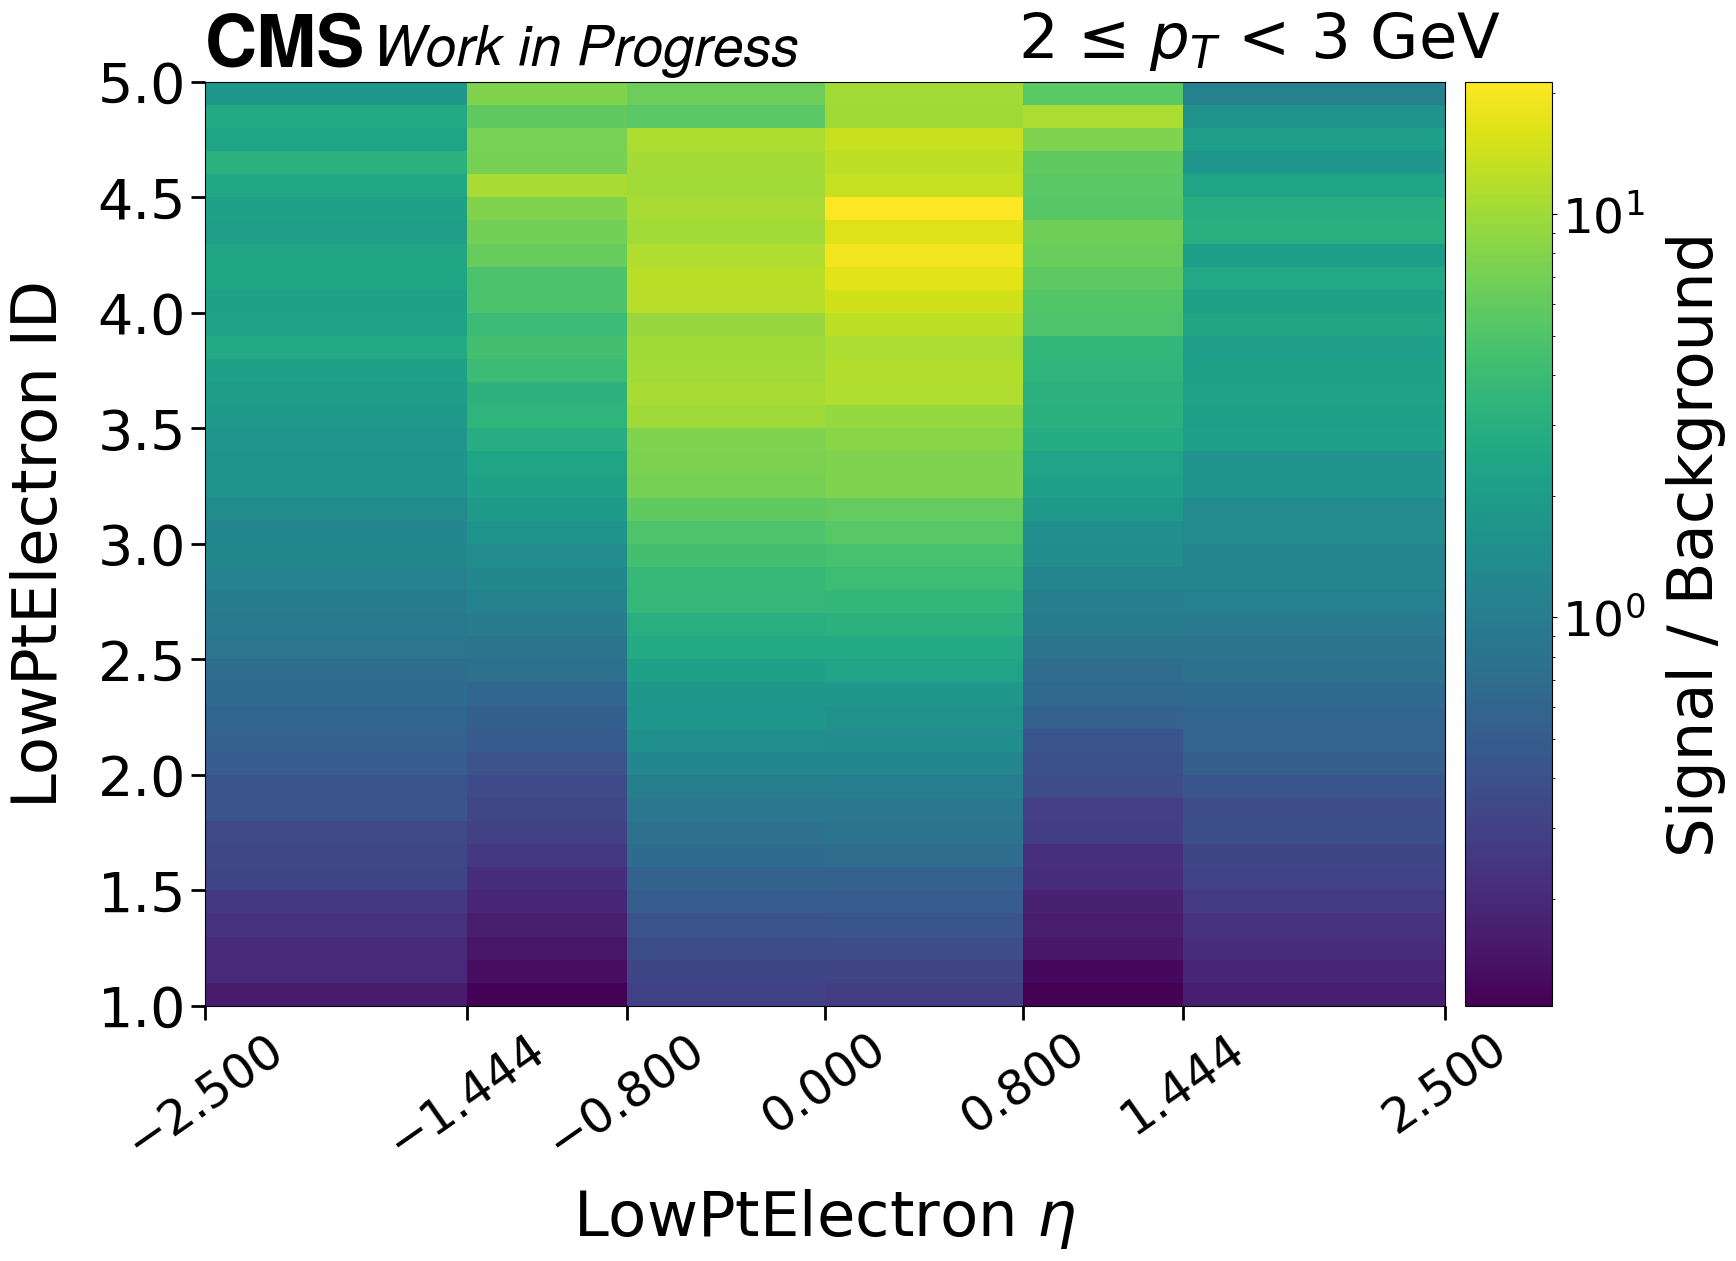

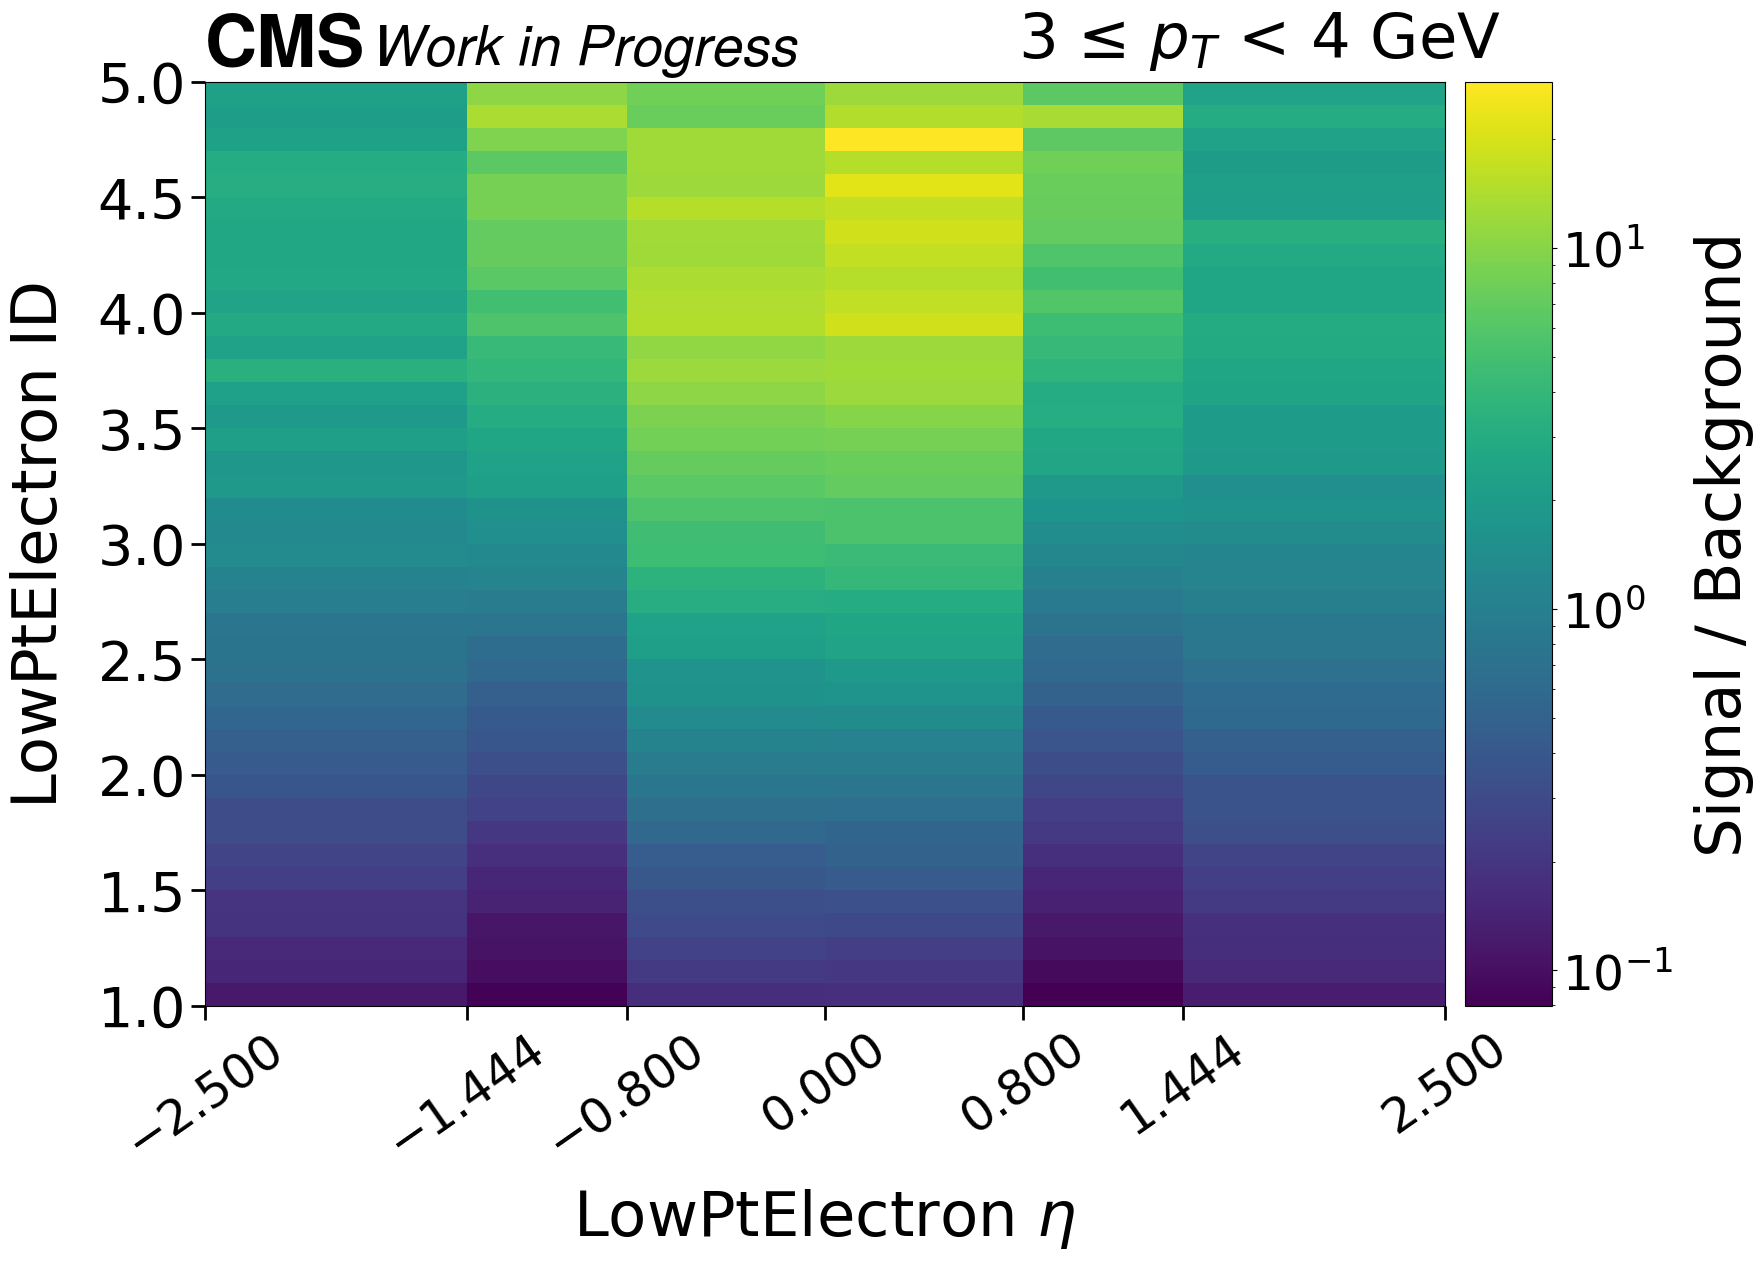

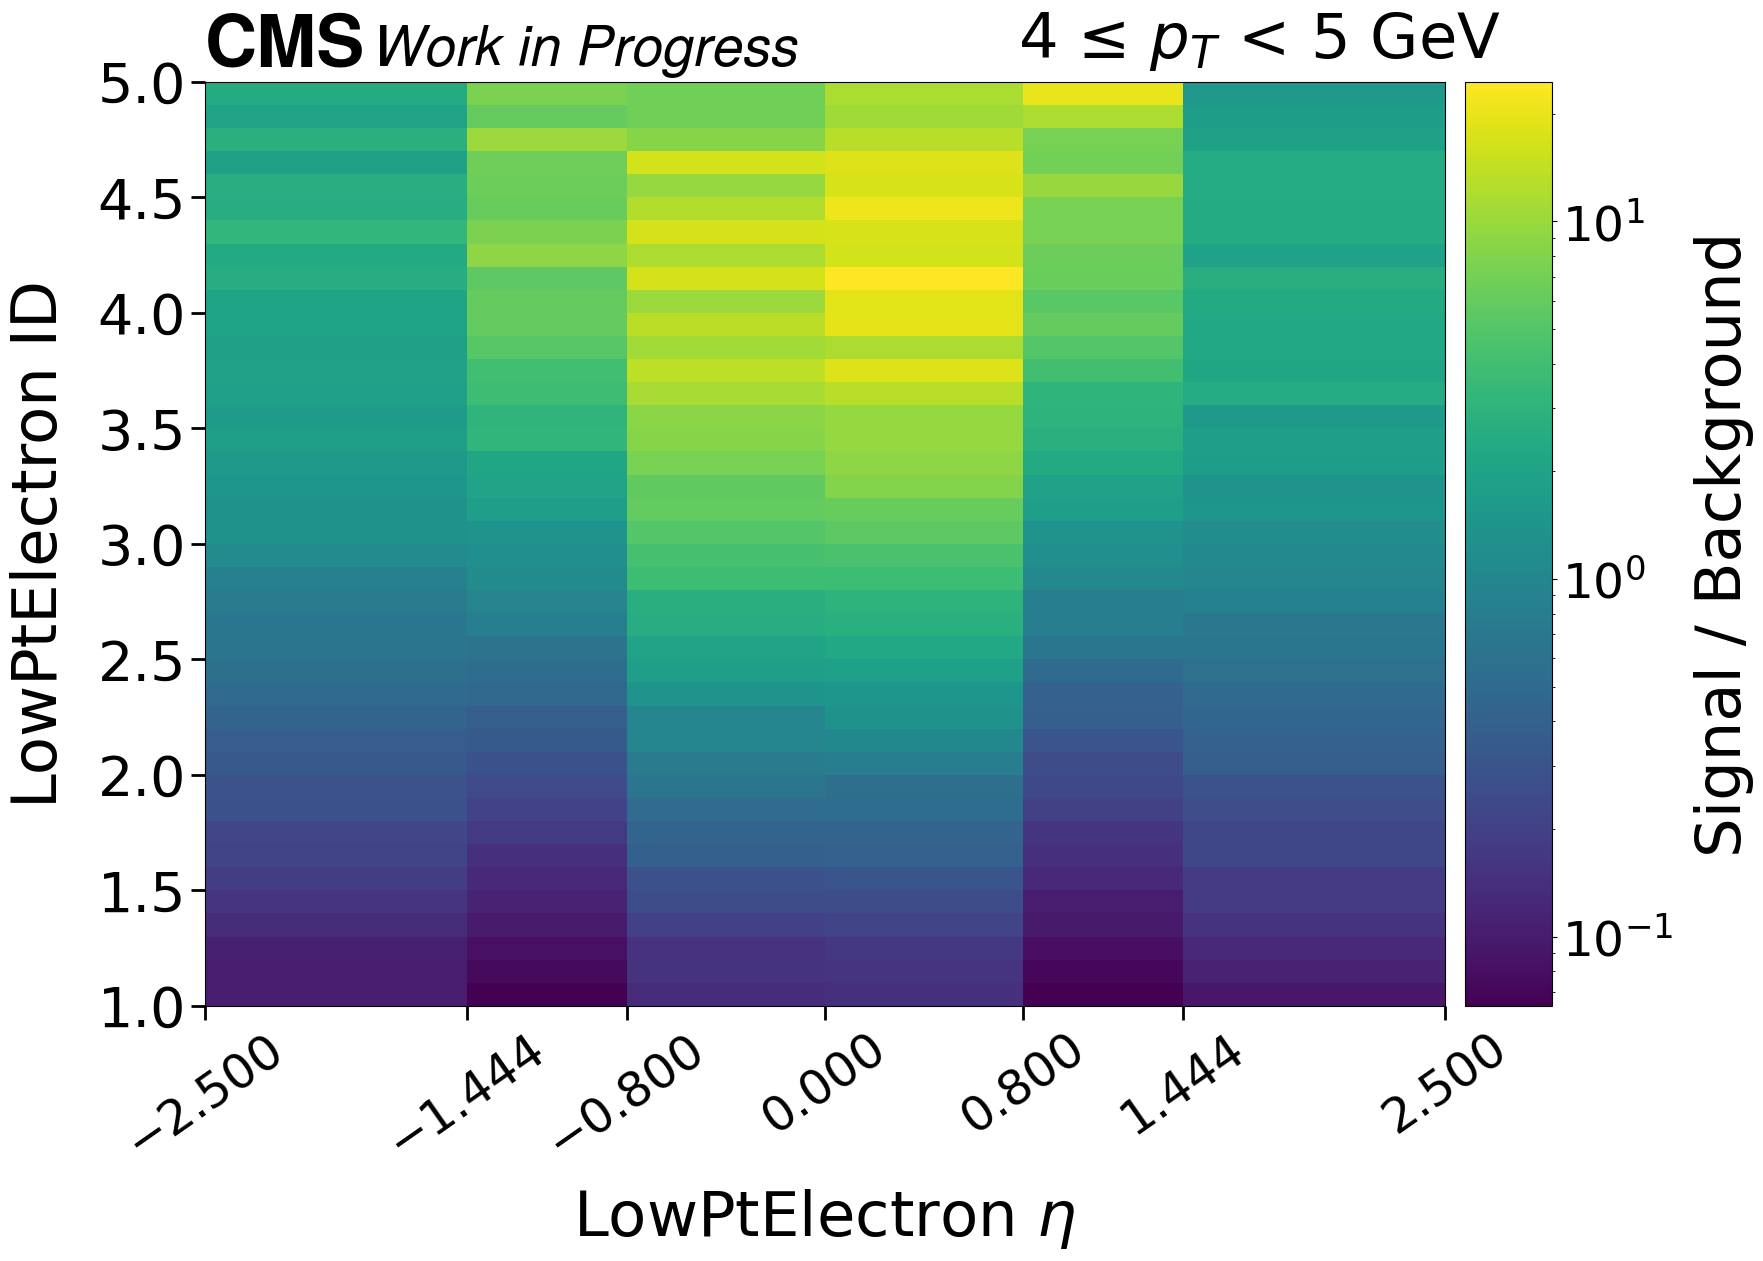

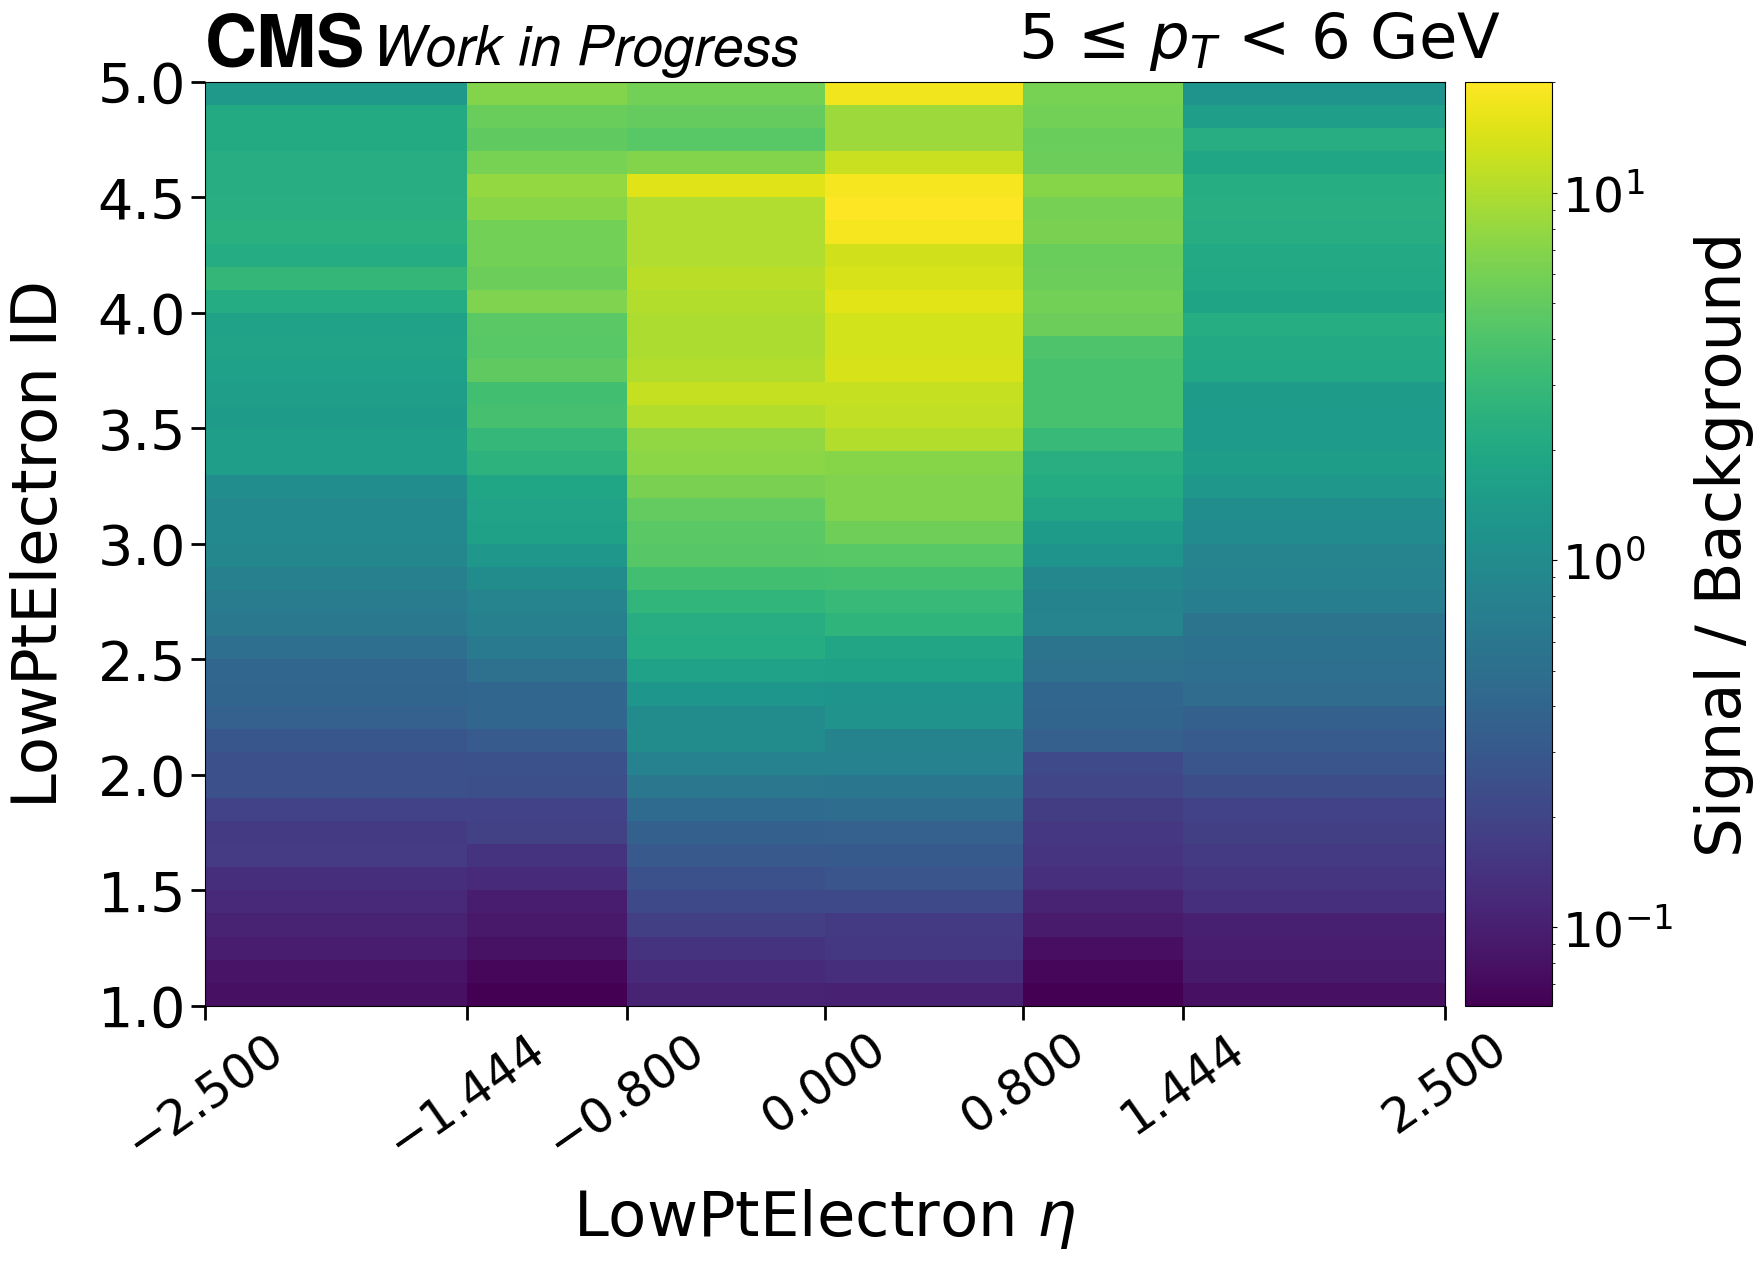

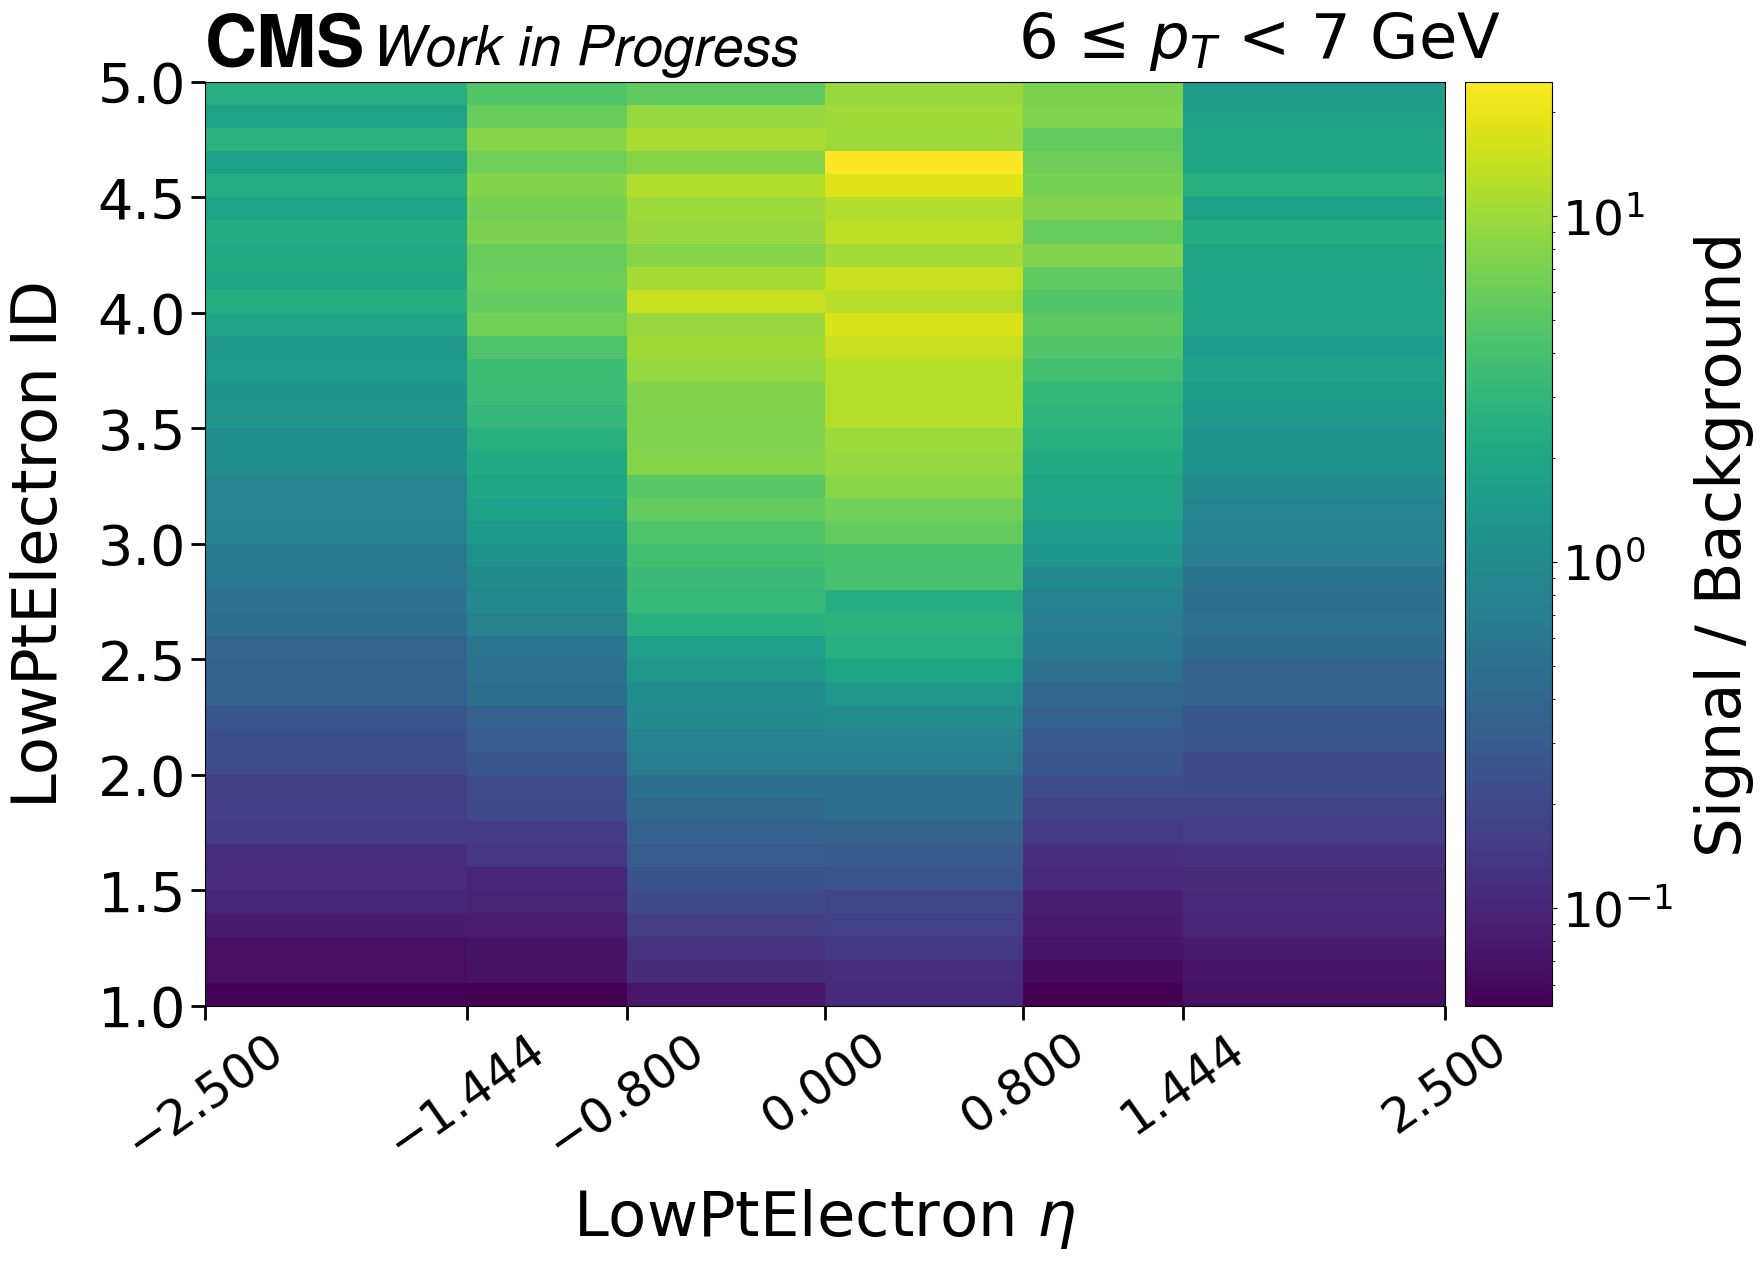

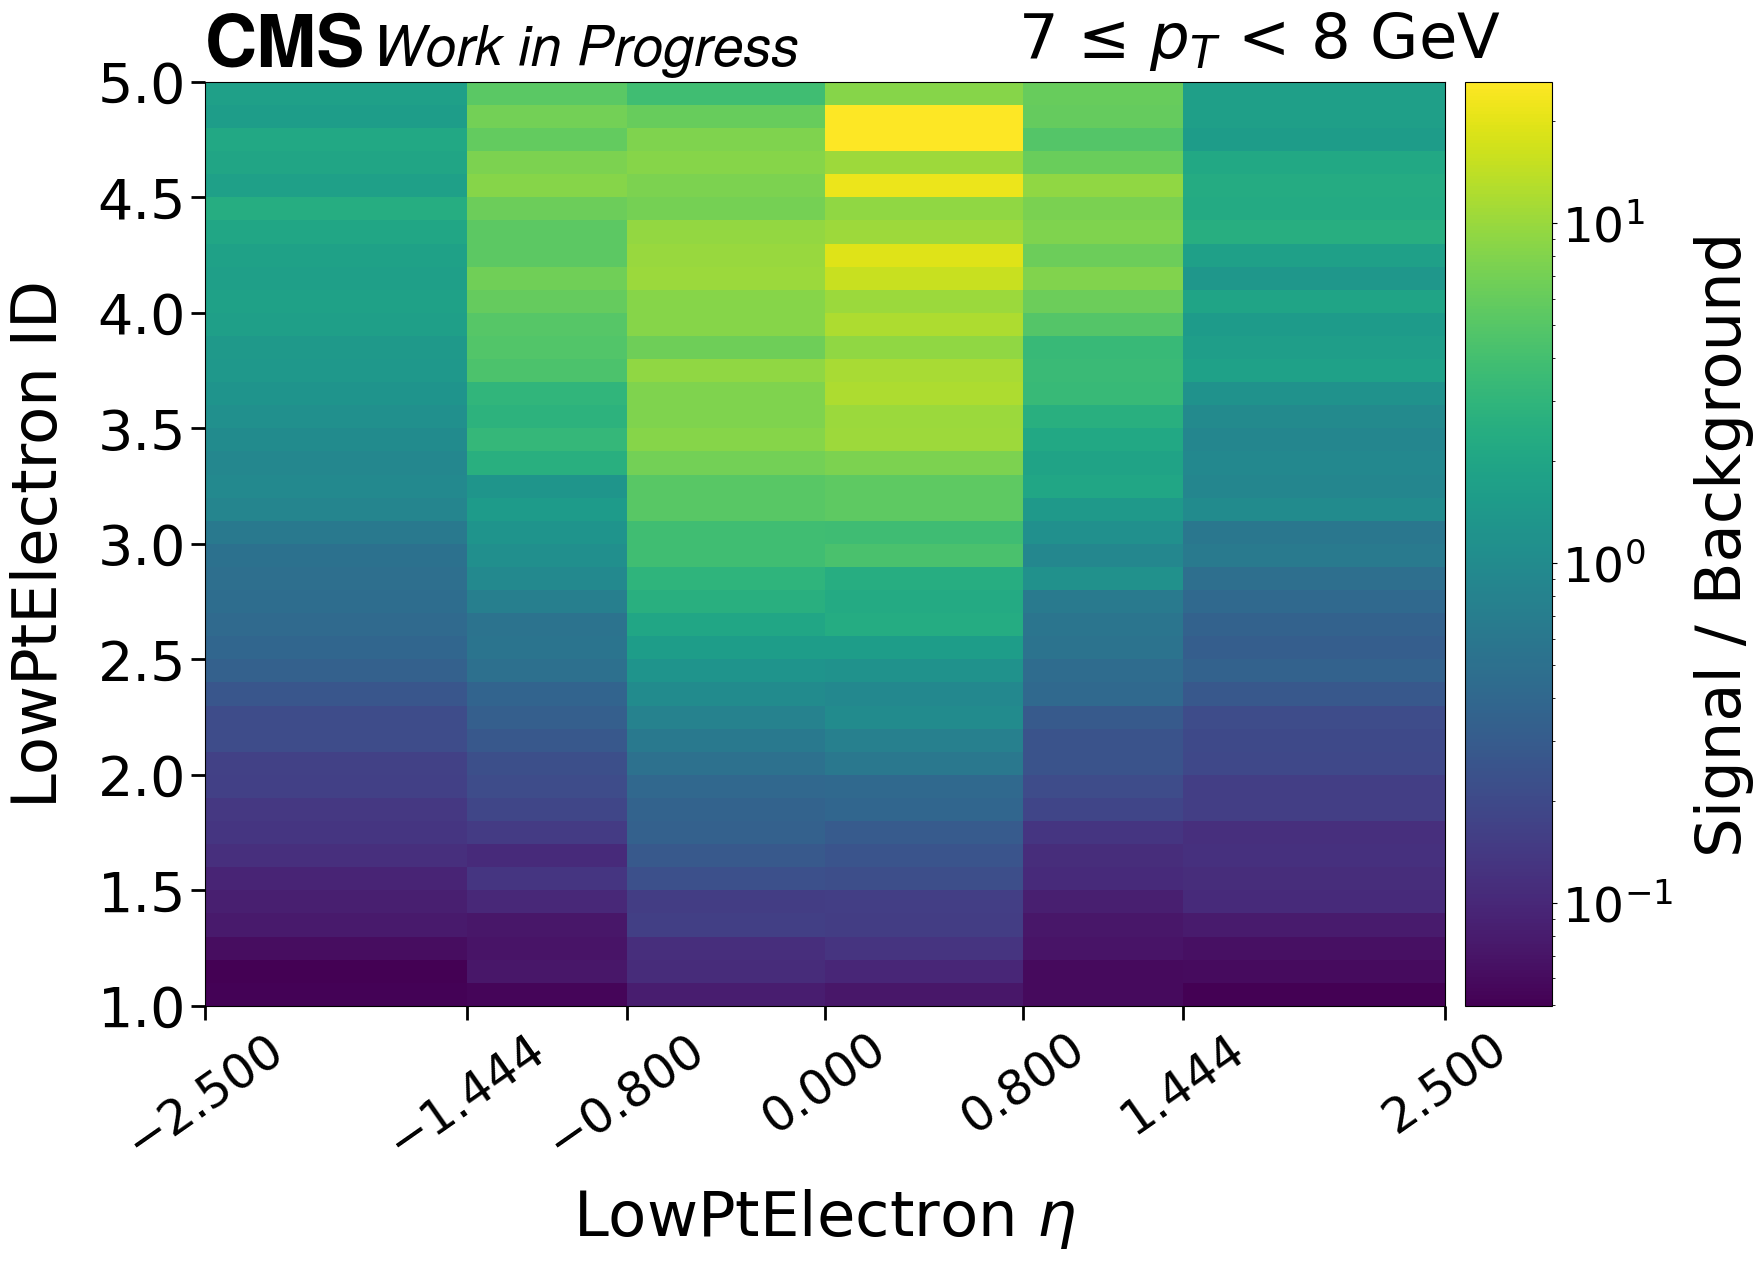

In [15]:
TChiWZ_2017 = results['TChiWZ2017UL']["lpte_hist"].integrate("eta_old").integrate("qual", [1j, 10j, 100j]).integrate("gen", [1j])
ttbar_2017_background = results['TTto2L2Nu2017UL']["lpte_hist"].integrate("eta_old").integrate("qual", [1j, 10j, 100j]).integrate("gen", [10j])

for pt in pts:
    result = make_AN_ID_eta_plot(
    TChiWZ_2017[pt*1j:(pt+1)*1j, :,:],
    ttbar_2017_background[pt*1j:(pt+1)*1j, :,:],
    title=f"{pt} ≤ $p_T$ < {pt + 1} GeV",
    log_color_scale=True,
    savefig=True,
    name=f"TChiWZ17UL_over_ttbar17UL_{pt}_{pt+1}"
)
    display(result.figure)

## AFTER CUTS:

In [16]:
results['SlepSnu2702802752023'].keys()

dict_keys(['lpte_hist_tagged', 'lpte_hist'])

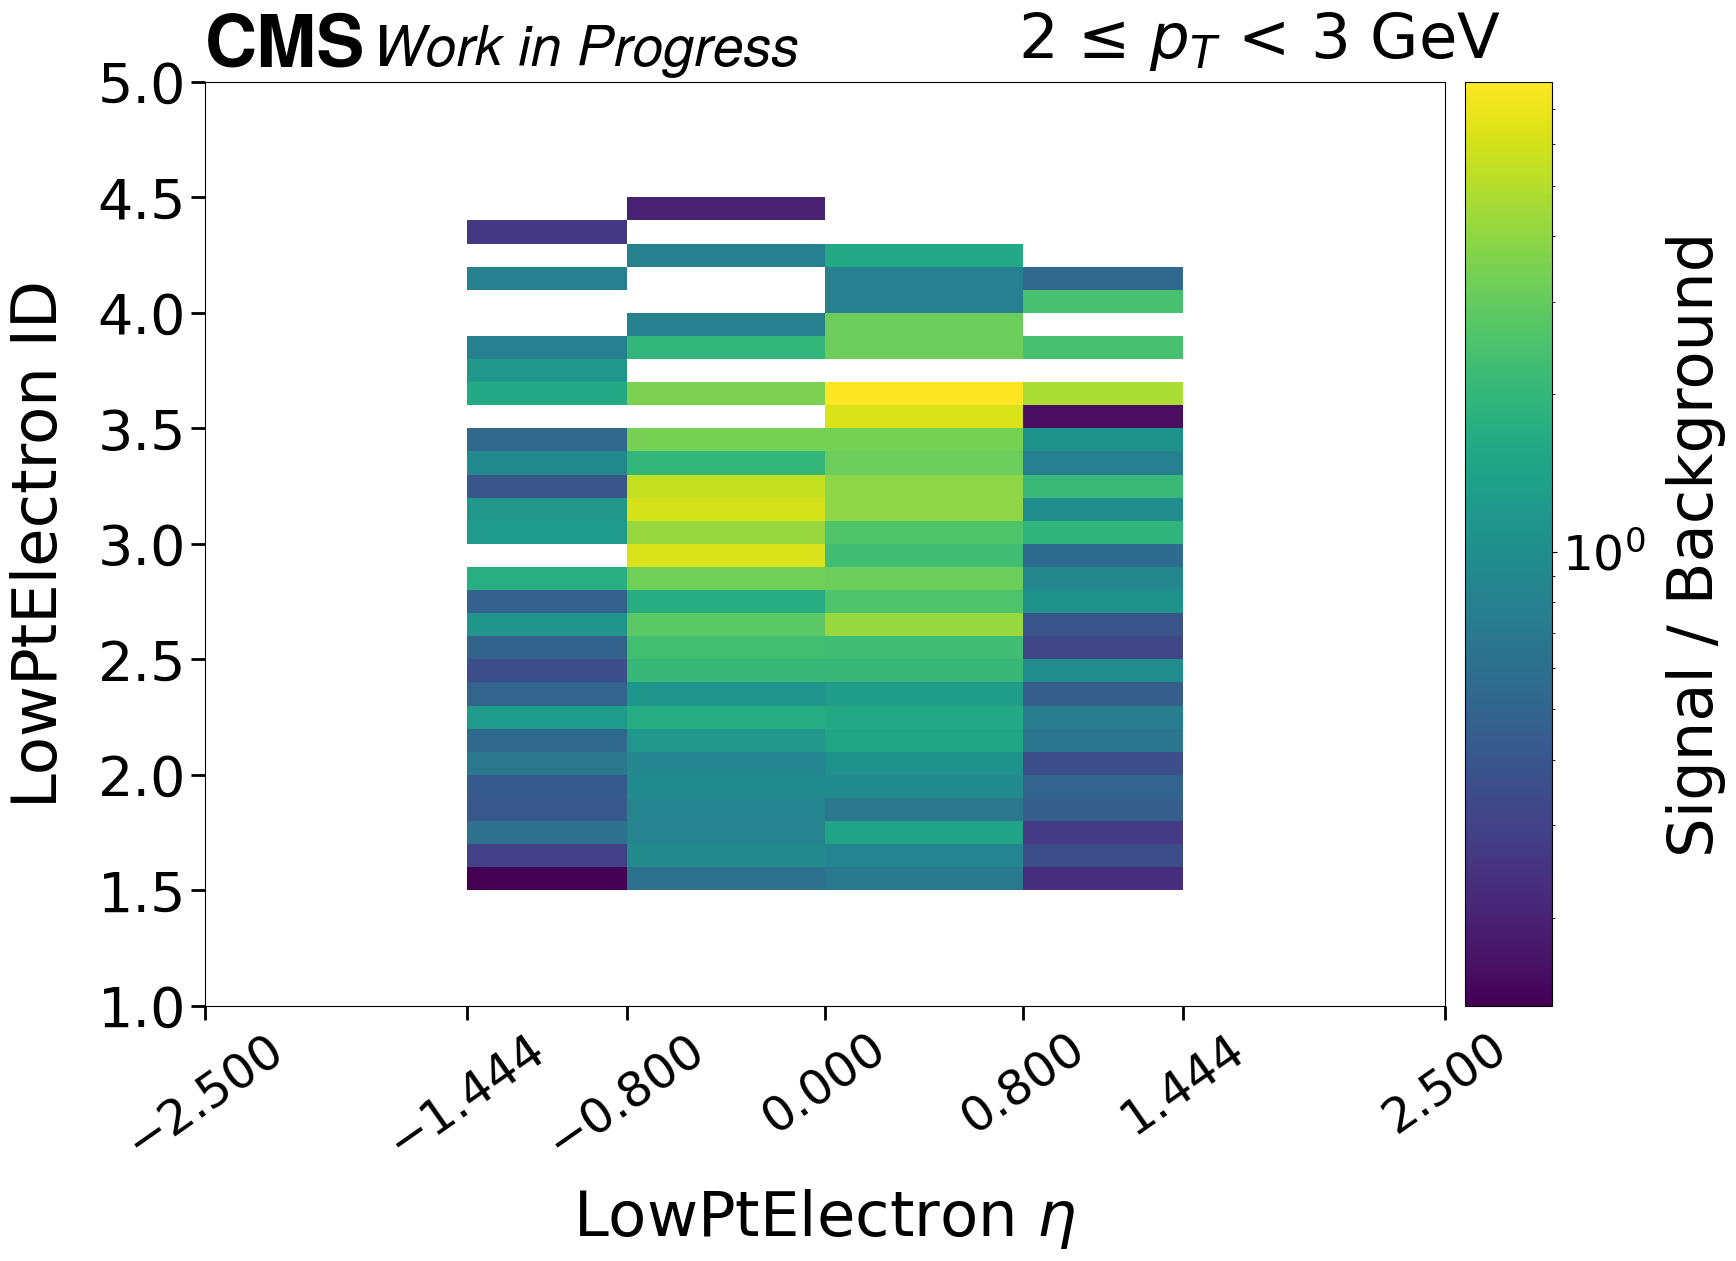

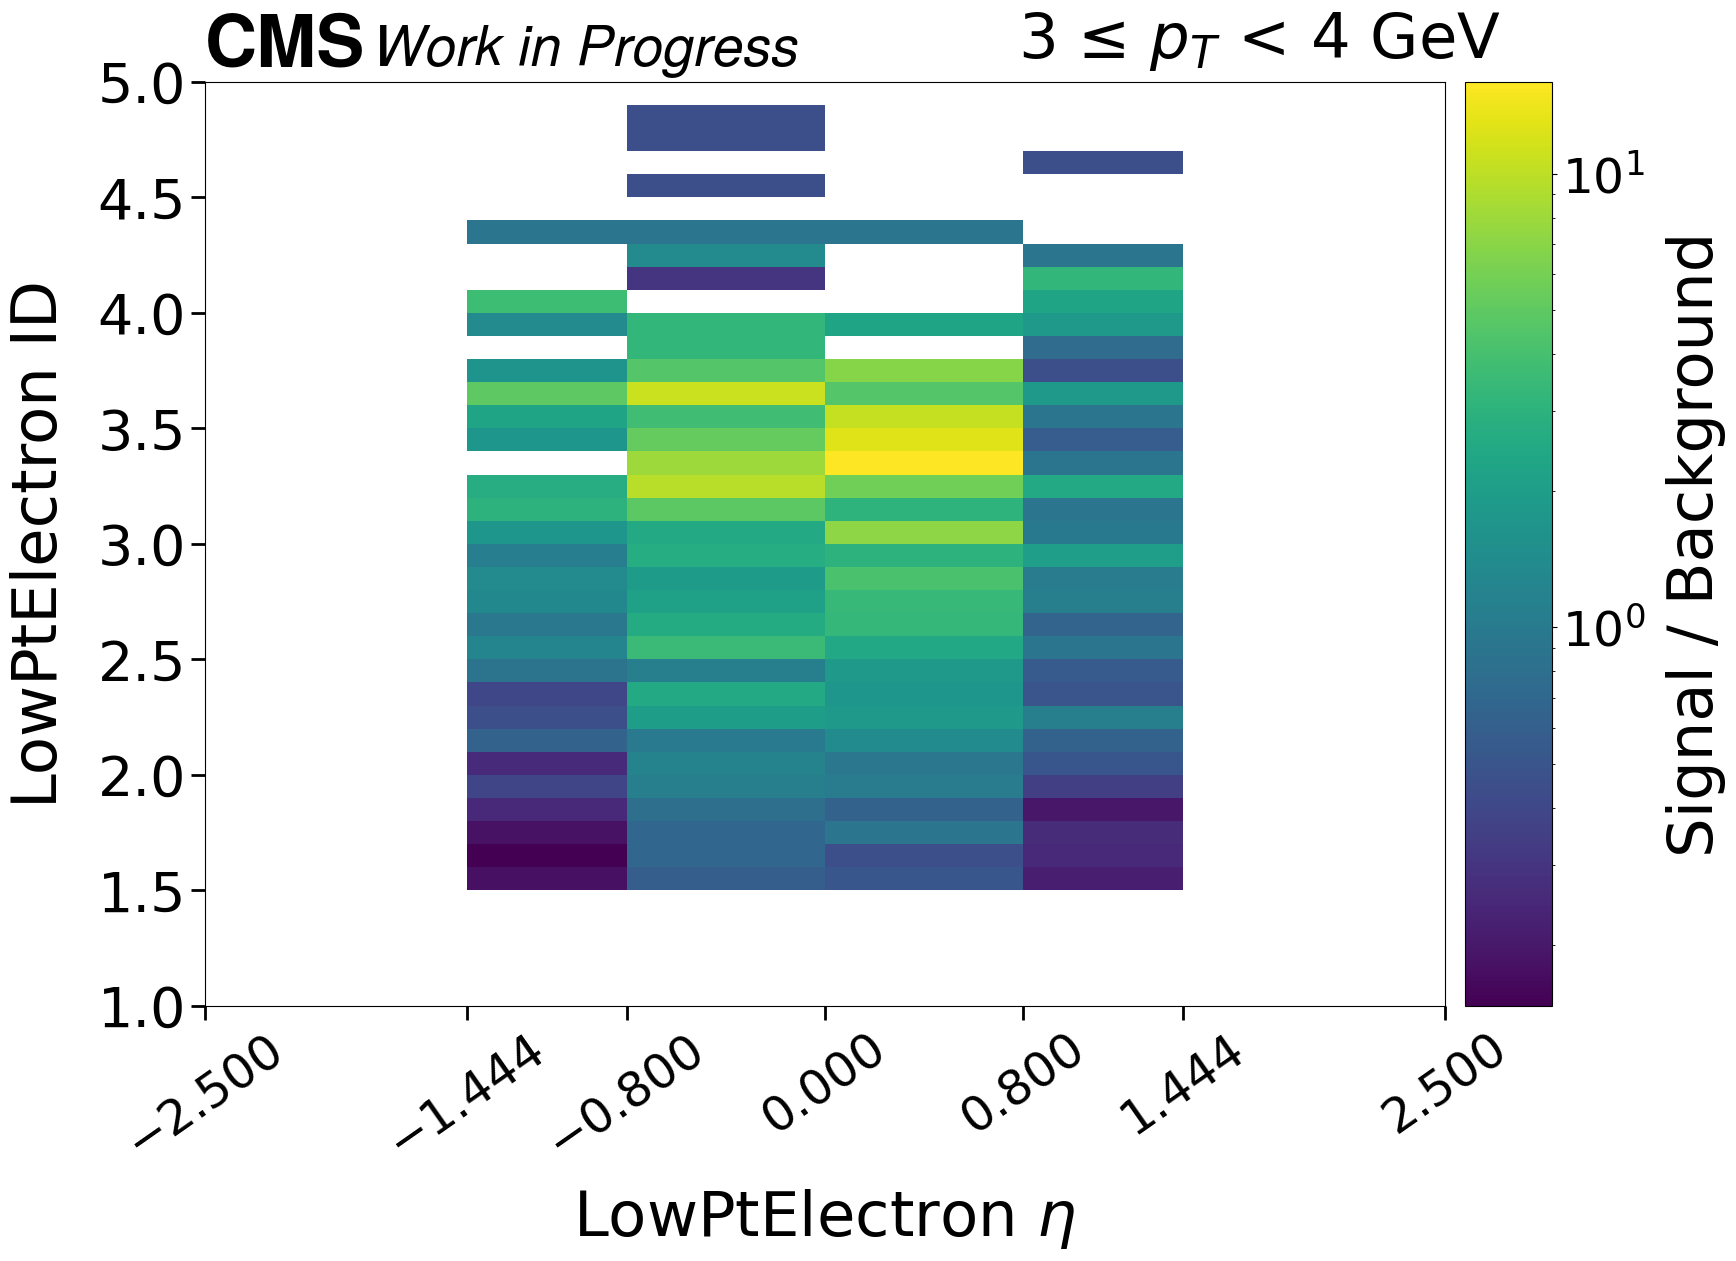

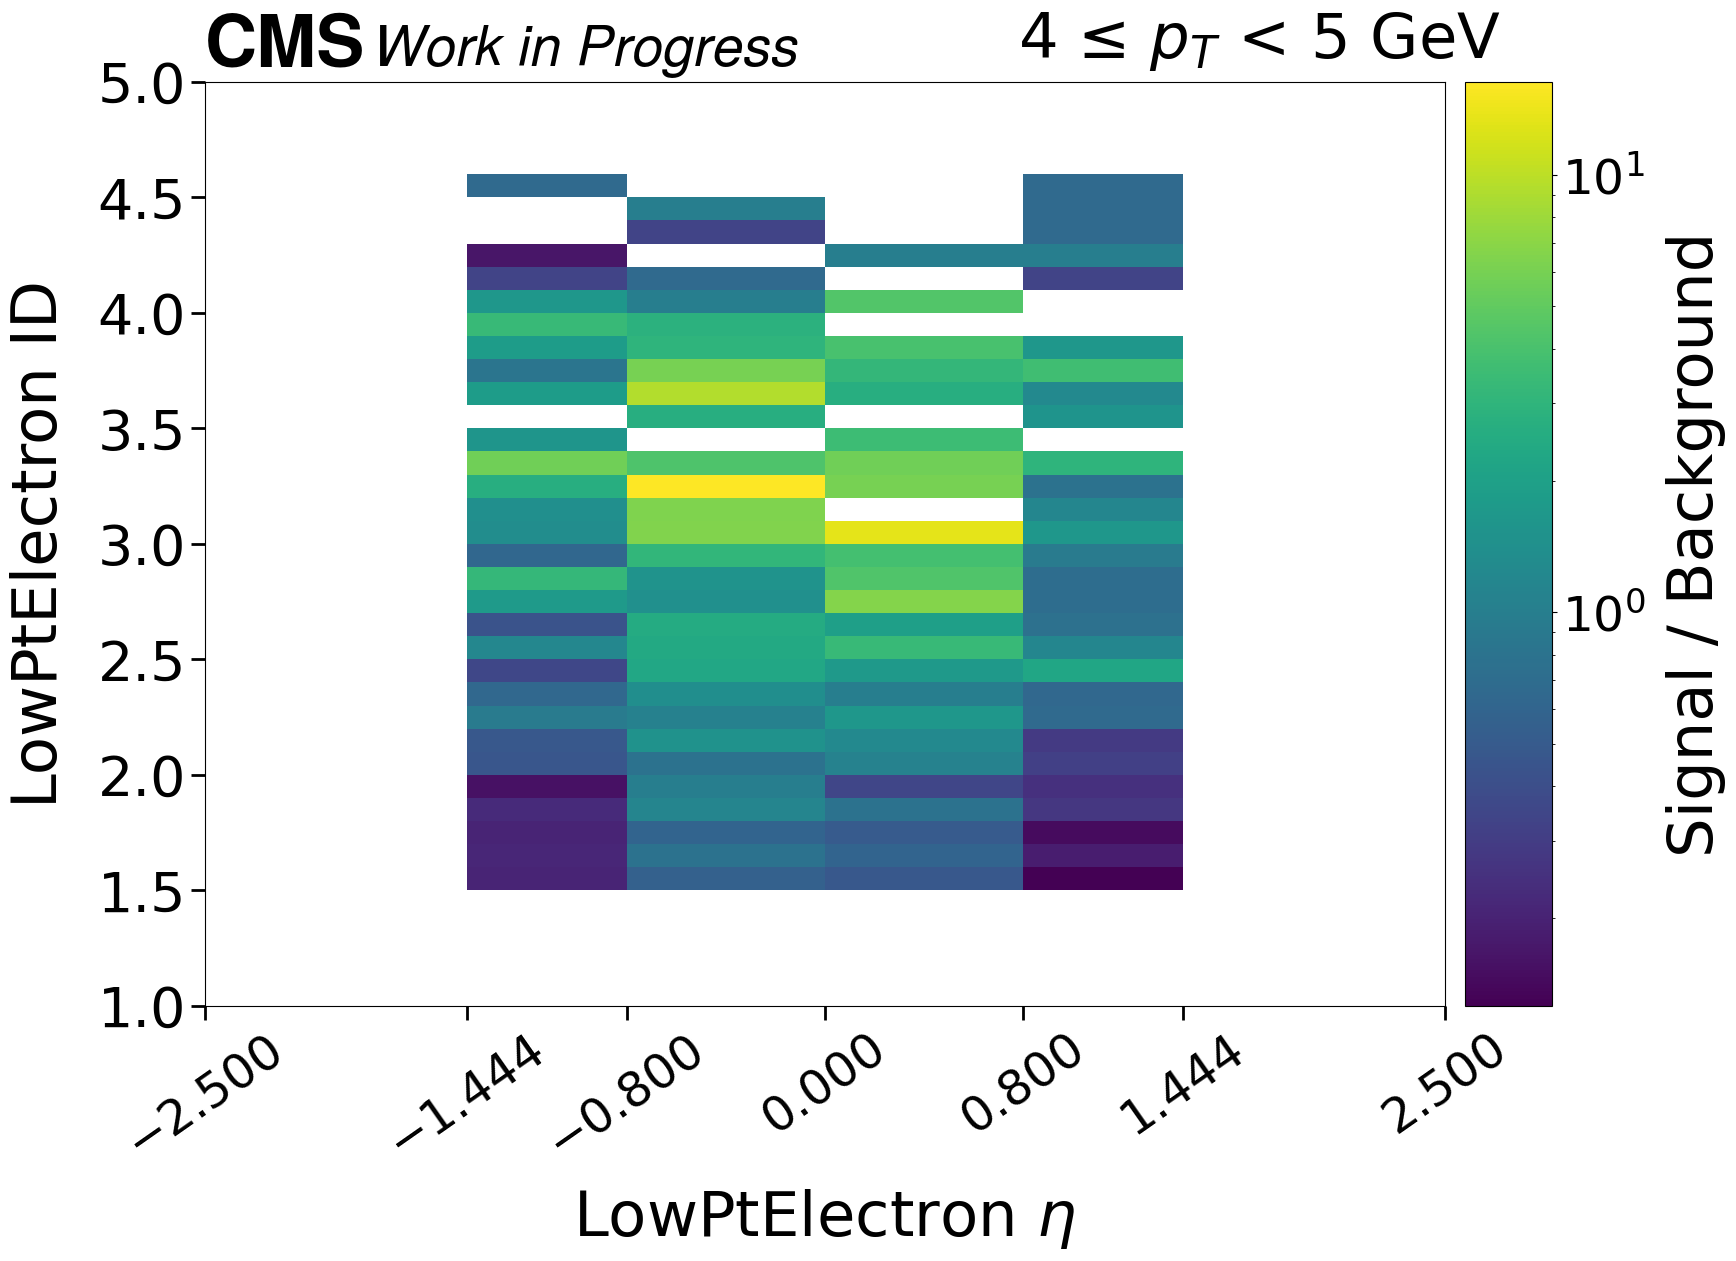

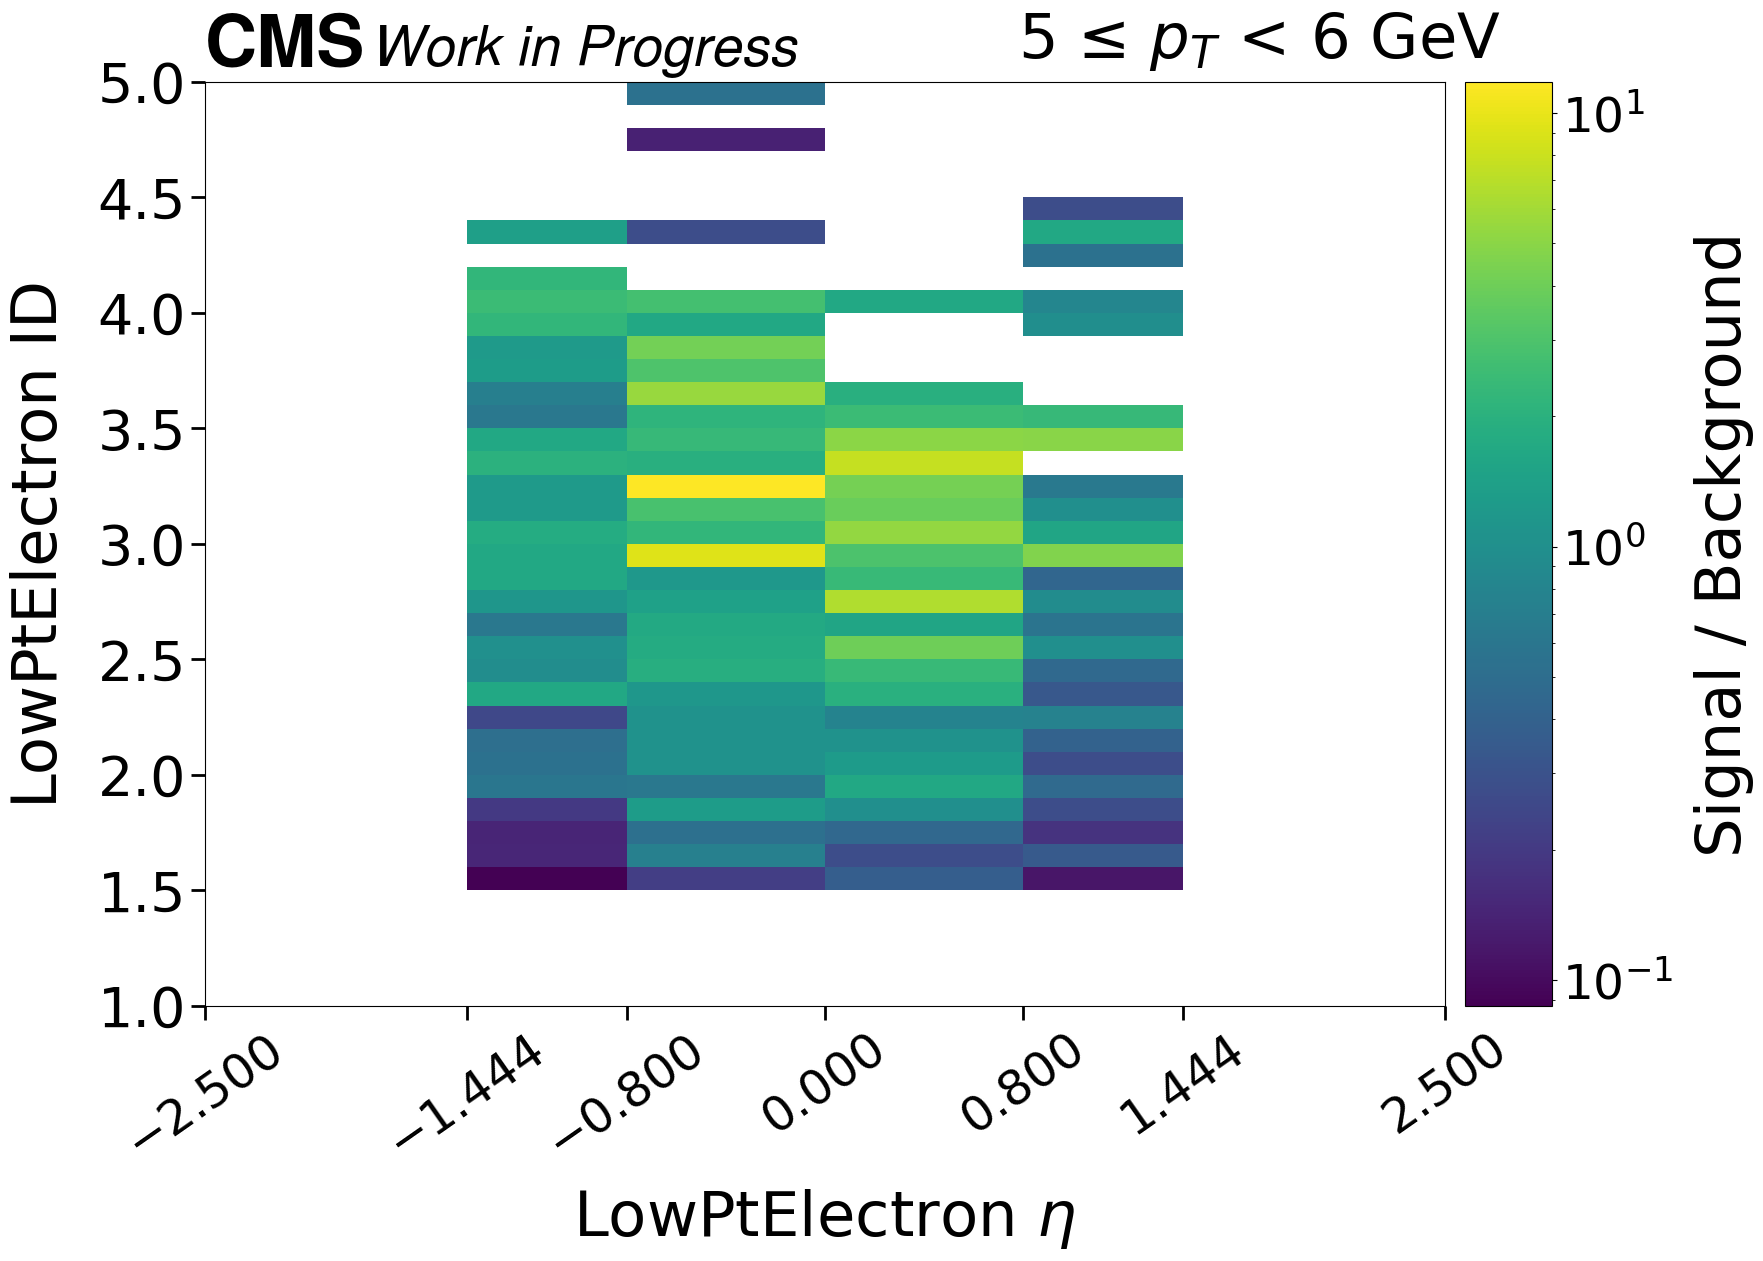

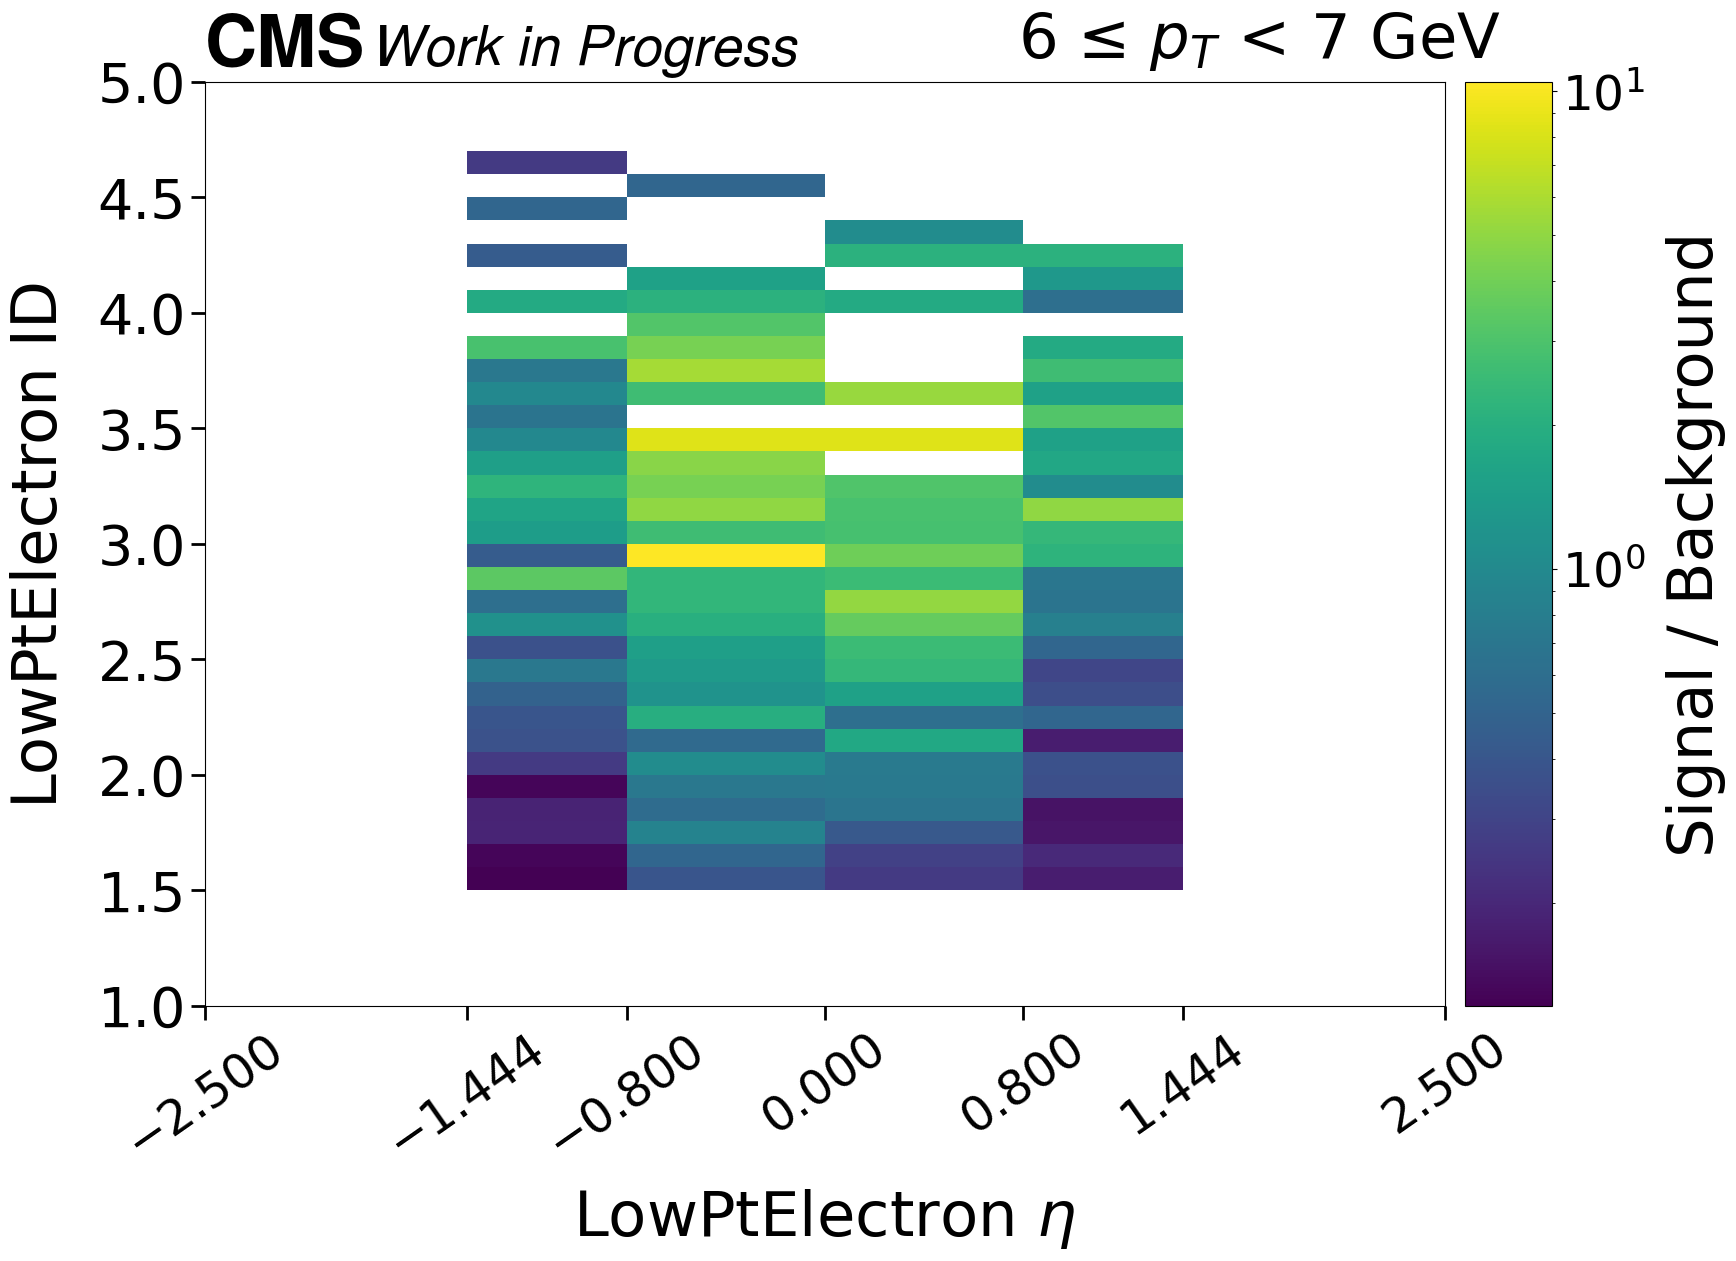

/usr/local/lib/python3.12/site-packages/boost_histogram/histogram.py:591: RuntimeWarning: divide by zero encountered in divide
  getattr(view, name)(other)
/usr/local/lib/python3.12/site-packages/boost_histogram/histogram.py:591: RuntimeWarning: invalid value encountered in divide
  getattr(view, name)(other)
/home/cms-jovyan/dwg_framework/src/plotting/ID_eta_tuning.py:57: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel("LowPtElectron $\eta$", fontsize=45, labelpad=15)


ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x7fbe720d2fc0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 1712x1200 with 2 Axes>

In [17]:
slepsnu_signal = results['SlepSnu2702802752023']["lpte_hist_tagged"].integrate("eta_old").integrate("qual", [1j, 10j, 100j]).integrate("gen", [1j])
ttbar_2023_background = results['TTto2L2Nu2023']["lpte_hist_tagged"].integrate("eta_old").integrate("qual", [1j, 10j, 100j]).integrate("gen", [10j])

for pt in pts:
    result = make_AN_ID_eta_plot(
    slepsnu_signal[pt*1j:(pt+1)*1j, :,:],
    ttbar_2023_background[pt*1j:(pt+1)*1j, :,:],
    title=f"{pt} ≤ $p_T$ < {pt + 1} GeV",
    log_color_scale=True,
    savefig=True,
    name=f"SlepSnu270280275_2023_over_ttbar2023_{pt}_{pt+1}_cuts"
)
    display(result.figure)

In [22]:
TChiWZ_2017 = results['TChiWZ2017UL']["lpte_hist_tagged"].integrate("eta_old").integrate("qual", [1j, 10j, 100j]).integrate("gen", [1j])
TChiWZ_2017

Hist(
  Regular(10, 0, 10, name='pt', label='LowPtElectron $p_T$ (GeV)'),
  Regular(40, 1, 5, name='ID', label='LowPtElectron ID'),
  Variable([-2.5, -1.4442, -0.8, 0, 0.8, 1.4442, 2.5], name='eta', label='LowPtElectron $\\eta$'),
  storage=Double()) # Sum: 2232928.0 (2280765.0 with flow)

In [ ]:
slepsnu_signal[pt*1j:(pt+1)*1j, :,:],
ttbar_2023_background[pt*1j:(pt+1)*1j, :,:],

s_o_b_clean.project("eta", "ID").plot()

In [57]:
TChiWZ_2017[2j:3j,:,:]

Hist(
  Regular(1, 2, 3, name='pt', label='LowPtElectron $p_T$ (GeV)'),
  Regular(40, 1, 5, name='ID', label='LowPtElectron ID'),
  Variable([-2.5, -1.4442, -0.8, 0, 0.8, 1.4442, 2.5], name='eta', label='LowPtElectron $\\eta$'),
  storage=Double()) # Sum: 529176.0 (2280765.0 with flow)

In [55]:
TChiWZ_2017[2j:3j,:,:].project("eta", "ID")

Hist(
  Variable([-2.5, -1.4442, -0.8, 0, 0.8, 1.4442, 2.5], name='eta', label='LowPtElectron $\\eta$'),
  Regular(40, 1, 5, name='ID', label='LowPtElectron ID'),
  storage=Double()) # Sum: 2232928.0 (2280765.0 with flow)

In [59]:
test.project("eta", "ID")

Hist(
  Variable([-2.5, -1.4442, -0.8, 0, 0.8, 1.4442, 2.5], name='eta', label='LowPtElectron $\\eta$'),
  Regular(40, 1, 5, name='ID', label='LowPtElectron ID'),
  storage=Double()) # Sum: 2232928.0 (2280765.0 with flow)

In [52]:
TChiWZ_2017[2j:3j,:,:].integrate("pt")

Hist(
  Regular(40, 1, 5, name='ID', label='LowPtElectron ID'),
  Variable([-2.5, -1.4442, -0.8, 0, 0.8, 1.4442, 2.5], name='eta', label='LowPtElectron $\\eta$'),
  storage=Double()) # Sum: 2232928.0 (2280765.0 with flow)

In [58]:
test = TChiWZ_2017[2j:3j,:,:]
test

Hist(
  Regular(1, 2, 3, name='pt', label='LowPtElectron $p_T$ (GeV)'),
  Regular(40, 1, 5, name='ID', label='LowPtElectron ID'),
  Variable([-2.5, -1.4442, -0.8, 0, 0.8, 1.4442, 2.5], name='eta', label='LowPtElectron $\\eta$'),
  storage=Double()) # Sum: 529176.0 (2280765.0 with flow)

In [51]:
test2 = TChiWZ_2017[2j:8j,:,:]
test2

Hist(
  Regular(6, 2, 8, name='pt', label='LowPtElectron $p_T$ (GeV)'),
  Regular(40, 1, 5, name='ID', label='LowPtElectron ID'),
  Variable([-2.5, -1.4442, -0.8, 0, 0.8, 1.4442, 2.5], name='eta', label='LowPtElectron $\\eta$'),
  storage=Double()) # Sum: 2232928.0 (2280765.0 with flow)

In [50]:
test.integrate("pt")

Hist(
  Regular(40, 1, 5, name='ID', label='LowPtElectron ID'),
  Variable([-2.5, -1.4442, -0.8, 0, 0.8, 1.4442, 2.5], name='eta', label='LowPtElectron $\\eta$'),
  storage=Double()) # Sum: 2232928.0 (2280765.0 with flow)

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fbe4f243830>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fbe4f2b7c50>, text=[])

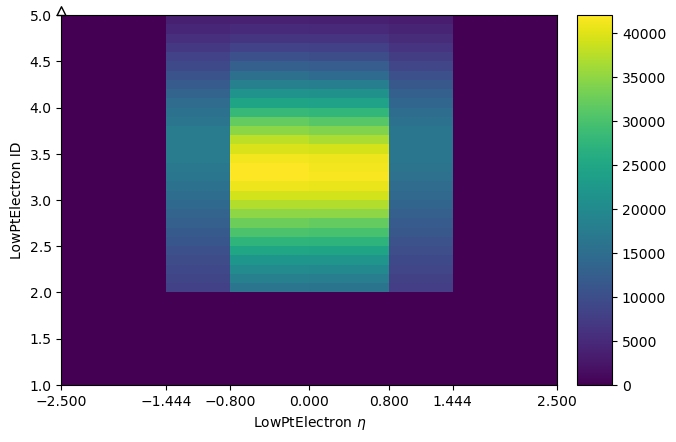

In [40]:
TChiWZ_2017[2j:3j,:,:].project("eta", "ID").plot()

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fbe4f7ad5b0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fbe4f260470>, text=[])

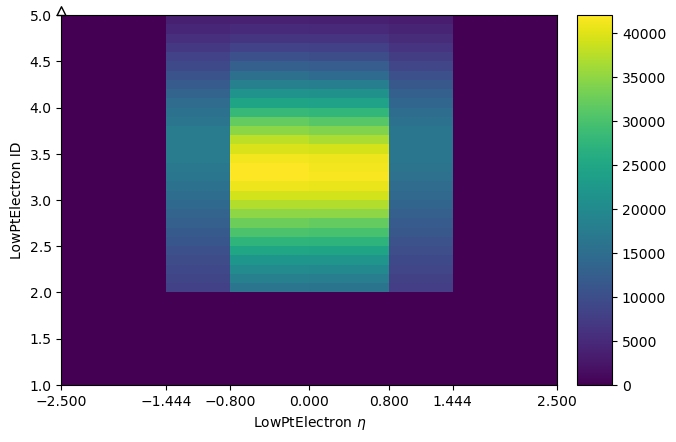

In [39]:
TChiWZ_2017[7j:8j,:,:].project("eta", "ID").plot()

In [24]:
TChiWZ_2017 = results['TChiWZ2017UL']["lpte_hist_tagged"].integrate("eta_old").integrate("qual", [1j, 10j, 100j]).integrate("gen", [1j])
ttbar_2017_background = results['TTto2L2Nu2017UL']["lpte_hist_tagged"].integrate("eta_old").integrate("qual", [1j, 10j, 100j]).integrate("gen", [10j])

for pt in pts:
    key = pt
    result = make_AN_ID_eta_plot(
    TChiWZ_2017.integrate("pt", [pt]),
    ttbar_2017_background.integrate("pt", [pt]),
    title=f"{pt} ≤ $p_T$ < {pt + 1} GeV",
    log_color_scale=True,
    savefig=True,
    name=f"TChiWZ17UL_over_ttbar17UL_{pt}_{pt+1}_cuts"
)
    display(result.figure)

RuntimeError: Axis 0 is not a categorical axis, cannot pick with list: regular(10, 0, 10, metadata={'name': 'pt', 'label': 'LowPtElectron $p_T$ (GeV)'}, options=underflow | overflow)

# GoldSilver without IDeta cuts

In [ ]:
slepsnu_signal_almostgold = results['SlepSnu2702802752023']["lpte_hist"].integrate("eta_old").integrate("gen", [1j]).integrate("qual", [100j])
ttbar_2023_background_almostgold = results['TTto2L2Nu2023']["lpte_hist"].integrate("eta_old").integrate("gen", [10j]).integrate("qual", [100j])

for pt in pts:
    result = make_AN_ID_eta_plot(
    slepsnu_signal_almostgold[pt*1j:(pt+1)*1j, :,:],
    ttbar_2023_background_almostgold[pt*1j:(pt+1)*1j, :,:],
    title=f"{pt} ≤ $p_T$ < {pt + 1} GeV",
    log_color_scale=True,
    savefig=True,
    name=f"SlepSnu270280275_2023_over_ttbar2023_{pt}_{pt+1}_almostgold"
)
    display(result.figure)

In [ ]:
slepsnu_signal_almostgold